# Escribir con nota

### ¿Puede un GPT afinado escribir una crítica con la nota que le pedimos?

Grupo Tango:
- Gustavo Betancur
- Mike Martinez
- Pedro Jojoa
- Juan Sebastian Orozco

**Sesión 4 — Generación de texto con modelos GPT** · MIIA, Universidad Icesi

---

| Sección | Contenido |
|---|---|
| 1 | El problema, cómo medir un texto generado y las hipótesis |
| 2 | Lo que heredamos de la Sesión 3: corpus, bandas, partición y métricas |
| 3 | EDA: el corpus visto por GPT-2 y lo que sabe el modelo base (figura 01) |
| 4 | Cómo se genera texto: nuestra función, comparada con la de Hugging Face |
| 5 | El juez: el clasificador de la Sesión 3, usado para medir |
| 6 | *Fine-tuning* con token de control (figuras 02 y 03) |
| 7 | ¿Escribe la nota que se le pide? (figuras 04 a 07) |
| 8 | El generador como clasificador, la prueba y el veredicto (figura 08) |
| 9 | Demo y conclusiones |

Tomamos el GPT-2 en español del notebook guía,
[`mrm8488/spanish-gpt2`](https://huggingface.co/mrm8488/spanish-gpt2), y lo afinamos con las críticas
de FilmAffinity de las dos entregas anteriores. A cada crítica le ponemos delante un token que dice su
banda de nota (`<|1-2|>` … `<|9-10|>`). La idea es poder pedirle después una crítica de una banda
concreta.

Para saber si lo logra usamos el BETO que entrenamos en la Sesión 3, que lee la nota en el texto
(0,554 de macro-F1 en prueba). Aquí no es el modelo que estudiamos sino el juez: si le pedimos al
generador una crítica `1-2` y BETO lee una `7-8`, el control falló.

**Resumen del resultado.** El modelo aprendió a escribir críticas de cine, pero no a escribir la nota
que se le pide. La causa es un error de diseño que encontramos después de la corrida: pusimos el token
de control en la primera posición del texto, y GPT-2 no usa lo que hay en esa posición. §6.3 lo muestra
y §9.2 lo explica.

---

## 1. El problema

### 1.1 La tarea

El notebook guía afina GPT-2 con chistes y concluye que el modelo cambia de estilo. Es una
observación cualitativa, porque no hay forma de medir si algo es un chiste.

Nosotros queríamos algo que se pudiera medir. El modelo tiene que escribir críticas de cine, y además
la crítica que se le pide, que aquí quiere decir una crítica con cierta nota. Para pedírsela usamos un
token de control: se escribe delante del texto y el modelo debería tenerlo en cuenta en todo lo que
sigue. Es la idea de CTRL (Keskar *et al.*, 2019) en su versión más simple: cinco tokens nuevos en el
vocabulario y ningún cambio en la arquitectura.

Un generador así serviría, por ejemplo, para crear ejemplos de la banda `1-2`, que es la que menos
datos tiene. Pero solo sirve si el control funciona, y eso hay que medirlo.

### 1.2 Cómo medir un texto generado

Hay tres cosas que medir, y ninguna reemplaza a las otras:

| Pregunta | Cómo se mide | Dónde |
|---|---|---|
| ¿Aprendió a escribir críticas? | perplejidad sobre críticas reales que no vio | §6.3 |
| ¿Escribe la banda que se le pide? | un juez: el BETO de la Sesión 3 lee la banda del texto generado | §7.1 |
| ¿Escribe cosas variadas, o copia? | *distinct-2*, repetición, y 8-gramas copiados del entrenamiento | §7.4 y §7.5 |

La perplejidad puede bajar aunque el control no funcione: un modelo que ignore el token y escriba una
crítica promedio también la baja. Y el juez puede dar un control perfecto con textos que repiten
siempre la misma frase. Por eso hacen falta las tres.

El juez tampoco es perfecto. Sobre críticas reales acierta un poco más de la mitad, así que su
resultado con críticas reales es el techo con el que comparamos todo lo generado (§5.3). Como segunda
opinión usamos el TF-IDF de la Sesión 3, que lee palabras sueltas en lugar de contexto.

### 1.3 Lo que heredamos de la Sesión 3

| De la Sesión 3 | Para qué sirve aquí |
|---|---|
| Corpus, bandas, partición por película y semilla, sin cambios | el generador y el juez ven los mismos 12.000 documentos de entrenamiento |
| BETO afinado (M3) | el juez, entrenado otra vez con la misma receta (§5.2) |
| TF-IDF uni+bi | el segundo juez y la referencia léxica de §8 |
| `evaluar()` | mide igual las críticas reales y las generadas |

### 1.4 Hipótesis

Las escribimos antes de entrenar, cada una con el criterio que la decide. La celda de §8.4 calcula el
veredicto a partir de los resultados.

> **H1. Un *prompt* no basta; el token de control sí.** Si se le pide la nota en lenguaje natural, el
> GPT-2 base no escribe la banda pedida (QWK entre banda pedida y banda leída < 0,20). Afinado con el
> token de control, sí lo hace (QWK ≥ 0,50).
>
> **H2. El generador escribe caricaturas.** El juez acierta más con las críticas generadas que con las
> reales, con el mismo número de textos por banda. Pensábamos que el modelo aprendería la crítica
> típica de cada banda y no sus matices.
>
> **H3. Lo que cuesta leer también cuesta escribir.** En la Sesión 3 la banda peor clasificada fue
> `3-4`. En las generadas, el *recall* promedio de los extremos (`1-2`, `9-10`) supera al de las tres
> bandas del medio en más de 0,15.
>
> **H4. La temperatura cambia variedad por control.** Al subirla, la diversidad sube y el control baja:
> ρ de Spearman entre temperatura y *distinct-2* ≥ +0,8, y entre temperatura y QWK ≤ −0,8.
>
> **H5. Si sabe escribir una crítica, sabe leerla.** Usado como clasificador con la regla de Bayes, el
> GPT-2 afinado supera al TF-IDF pero no llega a BETO.

H1, H2 y H3 se revisan en §7.1 a §7.3, H4 en §7.4 y H5 en §8.

---

## 2. Andamiaje

Esta sección es copia de la Sesión 3. Así el juez de §5 es el mismo instrumento que allá ya
probamos.

La celda siguiente fija el presupuesto. Con `S4_HUMO=1` se reduce al mínimo para una prueba rápida
de todo el notebook. Con el presupuesto real, la corrida tardó una hora en una T4 de Colab.

In [1]:
import os, re, sys, math, time, random, warnings, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

try:
    import google.colab          # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import torch
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FP16 = (DEVICE == "cuda")

HUMO = os.environ.get("S4_HUMO") == "1"

# Presupuesto. N_TRAIN y N_EVAL son los de la Sesión 3 y no se tocan: el juez depende de ellos.
N_TRAIN = 12_000
N_EVAL  = 4_000
N_GEN      = 100     # críticas generadas por banda y por configuración de decodificación
MAX_NUEVOS = 200     # tokens nuevos como máximo por crítica generada
N_BOOT     = 400     # remuestreos para el ruido de cada métrica
if HUMO:
    N_TRAIN, N_EVAL, N_GEN, MAX_NUEVOS, N_BOOT = 400, 300, 6, 30, 50

MODELO_GPT  = "mrm8488/spanish-gpt2"
MODELO_JUEZ = "dccuchile/bert-base-spanish-wwm-cased"

DATA = Path(os.environ.get("S4_DATA",
                           "data/filmaffinity" if IN_COLAB else "../data/filmaffinity"))
FIGS    = Path("figuras");    FIGS.mkdir(exist_ok=True)
RES     = Path("resultados"); RES.mkdir(exist_ok=True)
MODELOS = Path("modelos");    MODELOS.mkdir(exist_ok=True)

# Los dos entrenamientos se guardan en modelos/. Con False, una segunda corrida los carga en vez de
# repetirlos; si la sesión se corta a mitad, se pierde lo que estaba en curso y nada más.
REENTRENAR = False

print(f"colab={IN_COLAB}   semilla={SEED}   dispositivo={DEVICE}   humo={HUMO}")
print(f"presupuesto: {N_TRAIN:,} críticas de entrenamiento, {N_EVAL:,} de evaluación, "
      f"{N_GEN} generadas por banda y configuración")
print(f"generador: {MODELO_GPT}   ·   juez: {MODELO_JUEZ}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}  "
          f"({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")
else:
    print("AVISO: sin GPU esto es inviable con el presupuesto real. Usa Colab con acelerador GPU.")

colab=True   semilla=42   dispositivo=cuda   humo=False
presupuesto: 12,000 críticas de entrenamiento, 4,000 de evaluación, 100 generadas por banda y configuración
generador: mrm8488/spanish-gpt2   ·   juez: dccuchile/bert-base-spanish-wwm-cased
GPU: Tesla T4  (15.6 GB)


In [2]:
def asegurar(paquetes):
    # Instala en Colab lo que falte; en local avisa y no toca el entorno.
    faltan = []
    for modulo, pip in paquetes:
        try:
            __import__(modulo)
        except ImportError:
            faltan.append(pip)
    if faltan:
        if IN_COLAB:
            print(f"instalando: {' '.join(faltan)}…")
            get_ipython().run_line_magic("pip", "install -q " + " ".join(faltan))
        else:
            raise SystemExit(f"Faltan dependencias: pip install {' '.join(faltan)}")

asegurar([("transformers", "transformers"), ("datasets", "datasets"),
          ("accelerate", "accelerate"), ("scipy", "scipy")])

import transformers, datasets
print(f"transformers {transformers.__version__}   datasets {datasets.__version__}   "
      f"torch {torch.__version__}")

transformers 5.17.0   datasets 4.8.5   torch 2.11.0+cu130


### 2.1 Estilo de las figuras

El mismo de las entregas anteriores: azul para los valores, naranja para lo que señala el texto, y una
escala de colores ordenada para las cinco bandas. Las críticas reales van en gris claro.

In [3]:
AZUL, NARANJA = "#2a78d6", "#eb6834"
TINTA, TINTA_2, MALLA = "#0b0b0b", "#52514e", "#e4e3df"
GRIS_REAL = "#b9b7b1"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "font.size": 10, "font.family": "DejaVu Sans",
    "axes.edgecolor": MALLA, "axes.linewidth": 1.0,
    "axes.labelcolor": TINTA_2, "axes.titlecolor": TINTA,
    "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 9.5,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "grid.color": MALLA, "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})

def limpiar(ax, ejes=("top", "right")):
    for e in ejes:
        ax.spines[e].set_visible(False)
    return ax

def guardar(fig, nombre):
    fig.savefig(FIGS / f"{nombre}.png")
    return fig

COLOR_BANDA = [mpl.colormaps["RdYlBu"](v) for v in (0.06, 0.27, 0.5, 0.73, 0.94)]

### 2.2 El corpus, las bandas y la partición

Usamos [`naim-prog/filmaffinity-reviews-info`](https://huggingface.co/datasets/naim-prog/filmaffinity-reviews-info)
(licencia MIT), con las mismas cinco bandas y la misma partición por `film_id` de la Sesión 3. El
submuestreo se hace después de partir, igual que allá. La celda comprueba que ninguna película quede
en dos particiones.

Aquí eso importa más. Si una película estuviera en entrenamiento y en validación, el generador podría
acertar la banda repitiendo lo que se dijo de ella, y la prueba de copia de §7.5 no serviría.

In [4]:
BASE_HUB = ("https://huggingface.co/api/datasets/naim-prog/filmaffinity-reviews-info/"
            "parquet/")
FUENTES = {"criticas": "reviews/train/0.parquet", "peliculas": "information/train/0.parquet"}

DATA.mkdir(parents=True, exist_ok=True)
for nombre, ruta in FUENTES.items():
    destino = DATA / f"{nombre}.parquet"
    if not destino.exists():
        print(f"descargando {nombre}…")
        pd.read_parquet(BASE_HUB + ruta).to_parquet(destino, index=False)

criticas = pd.read_parquet(DATA / "criticas.parquet")

BANDAS = ["1-2", "3-4", "5-6", "7-8", "9-10"]
NOMBRE = {k: f"banda {BANDAS[k]}" for k in range(5)}
N_CLASES = len(BANDAS)

criticas = criticas[criticas.author_review_desc.fillna("").str.len() > 0].copy()
criticas["y"] = ((criticas.author_rating - 1) // 2).astype(int)
criticas["texto"] = (criticas.author_review_title.fillna("").str.strip() + "\n\n"
                     + criticas.author_review_desc.fillna("").str.strip())
print(f"críticas con texto: {len(criticas):,}")

descargando criticas…
descargando peliculas…
críticas con texto: 419,827


In [5]:
from sklearn.model_selection import GroupShuffleSplit

corte1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
i_tr, i_resto = next(corte1.split(criticas, groups=criticas.film_id))
resto = criticas.iloc[i_resto]
corte2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
i_va, i_te = next(corte2.split(resto, groups=resto.film_id))

train_full = criticas.iloc[i_tr].reset_index(drop=True)
val_full   = resto.iloc[i_va].reset_index(drop=True)
test_full  = resto.iloc[i_te].reset_index(drop=True)

# Submuestreamos DESPUÉS de partir, con el mismo generador y en el mismo orden que la Sesión 3.
rng = np.random.default_rng(SEED)
def recortar(df, n):
    if len(df) <= n:
        return df.reset_index(drop=True)
    sel = np.sort(rng.choice(len(df), n, replace=False))
    return df.iloc[sel].reset_index(drop=True)

df_train = recortar(train_full, N_TRAIN)
df_val   = recortar(val_full,   N_EVAL)
df_test  = recortar(test_full,  N_EVAL)

comp = pd.DataFrame({
    n: d.y.value_counts(normalize=True).sort_index() * 100
    for n, d in [("train_%", df_train), ("val_%", df_val), ("test_%", df_test)]
})
comp.index = BANDAS
print(f"usados: train {len(df_train):,}  val {len(df_val):,}  test {len(df_test):,}\n")
print(comp.round(2).to_string())

compartidas = (set(train_full.film_id) & set(val_full.film_id)) | \
              (set(train_full.film_id) & set(test_full.film_id))
print(f"\npelículas compartidas entre particiones : {len(compartidas)}   (debe ser 0)")
assert len(compartidas) == 0

usados: train 12,000  val 4,000  test 4,000

      train_%  val_%  test_%
1-2      8.58   8.95    8.77
3-4     12.77  12.32   12.65
5-6     25.34  25.35   24.38
7-8     32.52  34.30   33.15
9-10    20.79  19.08   21.05

películas compartidas entre particiones : 0   (debe ser 0)


### 2.3 Las métricas

`evaluar()` es la de la Sesión 3. Ahora la columna `particion` también puede ser `generadas`. En ese
caso `y_true` es la banda pedida y `y_pred` la banda que lee el juez. Así el control se mide con las
mismas métricas que la clasificación.

Para los textos generados la métrica principal es el **QWK**. Las bandas tienen orden, y pedir un
`1-2` y recibir un `3-4` es un error menor que recibir un `9-10`; el QWK tiene en cuenta esa
diferencia. Los conjuntos generados tienen el mismo número de textos por banda (`N_GEN`), así que el
desbalance de la Sesión 3 no afecta aquí.

`ruido()` calcula cuánto varía cada métrica si se remuestrean los textos. Sirve para saber si una
diferencia es real o casualidad. En la Sesión 3 eso lo hacían tres semillas de entrenamiento; aquí lo
que cambia es la muestra de textos.

In [6]:
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, cohen_kappa_score, mean_absolute_error)

REGISTRO = RES / "experimentos_s4.csv"
ETIQUETAS = list(range(N_CLASES))

def macro_f1(y, p):
    return f1_score(y, p, average="macro", labels=ETIQUETAS, zero_division=0)

def qwk(y, p):
    return cohen_kappa_score(y, p, weights="quadratic", labels=ETIQUETAS)

def evaluar(y_true, y_pred, nombre, particion="val", notas="",
            registrar=True, verbose=True):
    # Única función de evaluación del proyecto (la de la Sesión 3).
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    m = {
        "experimento": nombre,
        "particion":   particion,
        "macro_f1":    macro_f1(y_true, y_pred),
        "accuracy":    accuracy_score(y_true, y_pred),
        "qwk":         qwk(y_true, y_pred),
        "mae":         mean_absolute_error(y_true, y_pred),
        "adyacente":   float(np.mean(np.abs(y_true - y_pred) <= 1)),
        "notas":       notas,
    }
    if verbose:
        print(f"── {nombre}  ({particion})")
        print(f"   macro-F1 {m['macro_f1']:.4f}   accuracy {m['accuracy']:.4f}   "
              f"QWK {m['qwk']:.4f}   MAE {m['mae']:.4f}   adyacente {m['adyacente']:.4f}\n")
        print(classification_report(y_true, y_pred, labels=ETIQUETAS,
                                    target_names=BANDAS, digits=3, zero_division=0))
    if registrar:
        pd.DataFrame([m]).to_csv(REGISTRO, mode="a",
                                 header=not REGISTRO.exists(), index=False)
    m["confusion"] = confusion_matrix(y_true, y_pred, labels=ETIQUETAS)
    return m

def ruido(y, p, metrica=qwk, B=None, semilla=SEED):
    # Desviación típica de la métrica al remuestrear los textos con reemplazo.
    y = np.asarray(y); p = np.asarray(p)
    r = np.random.default_rng(semilla)
    vals = []
    for _ in range(B or N_BOOT):
        i = r.integers(0, len(y), len(y))
        vals.append(metrica(y[i], p[i]))
    return float(np.std(vals))

def umbral(*sds):
    # Dos desviaciones de la diferencia entre medidas independientes.
    return 2.0 * math.sqrt(sum(s * s for s in sds))

CONSTANTE = int(df_train.y.value_counts().idxmax())
b0 = evaluar(df_val.y, np.full(len(df_val), CONSTANTE), nombre="B0-banda-fija",
             notas=f"predice siempre la {NOMBRE[CONSTANTE]}", verbose=False)
print(f"piso B0 en validación: macro-F1 {b0['macro_f1']:.4f}   QWK {b0['qwk']:.4f}")

piso B0 en validación: macro-F1 0.1022   QWK 0.0000


### 2.4 Un cronómetro

El mismo de la Sesión 3. Hay dos entrenamientos y unas cinco mil generaciones, y queremos saber dónde
se va el tiempo.

In [7]:
CRONO = []

class medir:
    # Context manager que acumula cuánto costó cada paso.
    def __init__(self, etiqueta):
        self.etiqueta = etiqueta
    def __enter__(self):
        self.t0 = time.perf_counter()
        return self
    def __exit__(self, *exc):
        self.seg = time.perf_counter() - self.t0
        CRONO.append({"paso": self.etiqueta, "segundos": self.seg})
        total = sum(c["segundos"] for c in CRONO)
        print(f"   ⏱  {self.etiqueta}: {self.seg/60:.1f} min   (acumulado {total/60:.1f} min)")
        return False

print("cronómetro listo.")

cronómetro listo.


---

## 3. El corpus visto por GPT-2

La Sesión 2 ya hizo el EDA del corpus y la Sesión 3 lo miró con BETO. Ahora el modelo es otro y la
tarea también: no se trata de leer la crítica para ponerle una etiqueta sino de escribirla token por
token. Antes de entrenar revisamos tres cosas:

1. Si el tokenizador de GPT-2 parte el corpus mejor o peor que el de BETO (§3.1).
2. Cuánto contexto hace falta para que el modelo vea críticas completas, con su final (§3.2).
3. Qué sabe de críticas el modelo base antes de afinarlo (§3.3).

### 3.1 El tokenizador, y tres problemas que el guía no revisa

El tokenizador de GPT-2 trabaja con bytes, así que no tiene token desconocido: cualquier texto se
puede escribir, aunque una palabra rara puede quedar partida en muchas piezas.

Primero comparamos el token de fin de texto del tokenizador con el que dice la configuración del
modelo, y revisamos cuántas filas tiene la matriz de *embeddings*.

In [8]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tok = AutoTokenizer.from_pretrained(MODELO_GPT)
gpt_base = AutoModelForCausalLM.from_pretrained(MODELO_GPT).to(DEVICE).eval()

FILAS_EMB = gpt_base.get_input_embeddings().weight.shape[0]
EOS_CFG = gpt_base.config.eos_token_id

print(f"tokenizador : {type(tok).__name__}, {len(tok):,} entradas, "
      f"eos = {tok.eos_token!r} (id {tok.eos_token_id})")
print(f"modelo      : {FILAS_EMB:,} filas de embeddings, contexto de "
      f"{gpt_base.config.n_positions} posiciones, "
      f"{sum(p.numel() for p in gpt_base.parameters())/1e6:.1f} M de parámetros")
print(f"config      : eos_token_id = {EOS_CFG}  →  en el vocabulario es "
      f"{tok.convert_ids_to_tokens(EOS_CFG)!r}")
print(f"relleno     : el tokenizador trae pad = {tok.pad_token!r}; "
      f"en su vocabulario existe '<pad>' con id {tok.convert_tokens_to_ids('<pad>')}")

SIN_FILA = [i for i in range(FILAS_EMB, len(tok)) if i != tok.eos_token_id]
if tok.eos_token_id >= FILAS_EMB:
    print(f"\n⚠ El eos del tokenizador (id {tok.eos_token_id}) no tiene fila en la matriz de "
          f"embeddings ({FILAS_EMB}).\n  El modelo base nunca vio un fin de texto: no sabe parar.")
if SIN_FILA:
    print(f"⚠ Además, {len(SIN_FILA)} piezas normales del tokenizador tampoco tienen fila: "
          f"{tok.convert_ids_to_tokens(SIN_FILA)}")

# Sin esto, la primera crítica que contenga una de esas piezas tumba la GPU con un
# 'device-side assert'. Las filas nuevas nacen como la media de las existentes.
gpt_base.resize_token_embeddings(len(tok))
print(f"\nmodelo base redimensionado a {gpt_base.get_input_embeddings().weight.shape[0]:,} filas")

config.json:   0%|          | 0.00/883 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/226 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/846k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/505k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  510MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


tokenizador : GPT2Tokenizer, 50,266 entradas, eos = '<|endoftext|>' (id 50265)
modelo      : 50,257 filas de embeddings, contexto de 1024 posiciones, 124.4 M de parámetros
config      : eos_token_id = 50256  →  en el vocabulario es 'Ġtraduci'
relleno     : el tokenizador trae pad = None; en su vocabulario existe '<pad>' con id 1

⚠ El eos del tokenizador (id 50265) no tiene fila en la matriz de embeddings (50257).
  El modelo base nunca vio un fin de texto: no sabe parar.
⚠ Además, 8 piezas normales del tokenizador tampoco tienen fila: ['Ġintersectorial', 'Ġmeridionales', 'ĠAung', 'Ġcadete', 'lamaciones', 'moni', 'Bene', 'Doro']

modelo base redimensionado a 50,266 filas


La celda muestra tres problemas en la pareja modelo–tokenizador:

- El tokenizador dice que el fin de texto es `<|endoftext|>`, con el id 50265. La matriz de
  *embeddings* del modelo solo tiene 50.257 filas, así que ese token no existe para el modelo. La
  configuración, por su parte, dice que el fin de texto es el id 50256, que en este vocabulario es el
  pedazo de palabra `traduci`. Resultado: el modelo base no sabe terminar un texto. Además, si no se le
  pasa `eos_token_id` a `generate()`, corta cada vez que escribe *traduci*.
- Hay ocho piezas comunes del tokenizador (`intersectorial`, `cadete`, `moni`…), con ids entre 50257 y
  50264, que tampoco tienen fila. Son raras, unas pocas por millón de tokens en este corpus, pero una
  sola hace que la GPU falle con un *device-side assert* que no dice qué token fue. Lo encontramos así,
  en la prueba de humo.
- El guía usa `pad_token = eos_token`. `DataCollatorForLanguageModeling` ignora en la pérdida todo lo
  que sea relleno, y con eso también el fin de texto, así que el modelo afinado tampoco aprendería a
  terminar. El vocabulario ya trae su propio `<pad>` (id 1) y usamos ese.

Por eso el `resize_token_embeddings(len(tokenizer))` del guía es necesario, y aquí lo aplicamos también
al modelo base. En §7.1 medimos cuántas críticas generadas terminan solas, para comprobar que el
arreglo funcionó.

In [9]:
tok.pad_token = "<pad>"
PAD_ID = tok.pad_token_id
EOS_ID = tok.eos_token_id
assert PAD_ID != EOS_ID

tok_beto = AutoTokenizer.from_pretrained(MODELO_JUEZ)

N_SONDA = 3_000 if not HUMO else 200
sonda = df_train.sample(min(N_SONDA, len(df_train)), random_state=SEED).reset_index(drop=True)
n_palabras = sonda.texto.str.split().apply(len).values
n_gpt  = np.array([len(x) for x in tok(list(sonda.texto))["input_ids"]])
n_beto = np.array([len(x) for x in tok_beto(list(sonda.texto), add_special_tokens=False)["input_ids"]])
fert_gpt  = n_gpt  / np.maximum(n_palabras, 1)
fert_beto = n_beto / np.maximum(n_palabras, 1)

print(f"fertilidad GPT-2 : {fert_gpt.mean():.3f} tokens por palabra")
print(f"fertilidad BETO  : {fert_beto.mean():.3f} tokens por palabra")
print(f"crítica mediana  : {np.median(n_palabras):.0f} palabras → "
      f"{np.median(n_gpt):.0f} tokens de GPT-2, {np.median(n_beto):.0f} de BETO")

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (547 > 512). Running this sequence through the model will result in indexing errors


fertilidad GPT-2 : 1.330 tokens por palabra
fertilidad BETO  : 1.330 tokens por palabra
crítica mediana  : 191 palabras → 251 tokens de GPT-2, 250 de BETO


### 3.2 Cuánto contexto hace falta

En clasificación, cortar una crítica le quita información al modelo. En generación además le quita el
final: una crítica cortada no termina en `<|endoftext|>`, y el modelo solo aprende a terminar con las
que caben completas. Por eso aquí el criterio no es la mediana, como en la Sesión 3, sino qué
proporción de críticas cabe entera, con su token de control al inicio y el fin de texto al final.

GPT-2 acepta 1024 posiciones, el doble que BETO, pero el costo de la atención crece con el cuadrado
de la longitud. La regla, escrita antes de mirar: usar el corte más corto entre 256, 384 y 512 que deje
completas al menos tres de cada cuatro críticas.

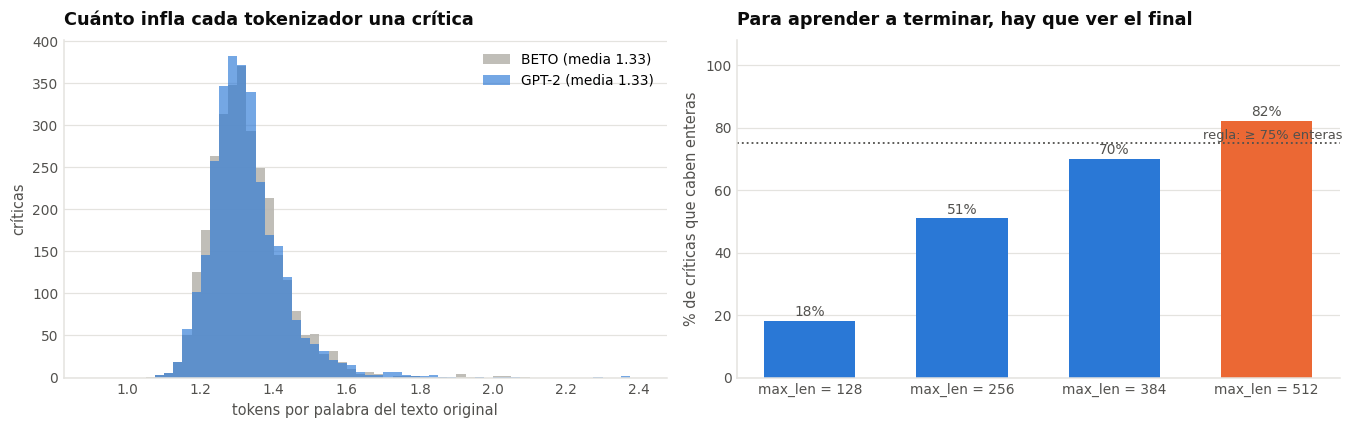

128    18.1
256    50.9
384    70.0
512    82.2

MAX_LEN_LM = 512   (lote 4 × acumulación 4 = 16)


In [10]:
CORTES = [128, 256, 384, 512]
largos = n_gpt + 2          # token de control + texto + fin de texto
completas = {c: 100 * float(np.mean(largos <= c)) for c in CORTES}

MAX_LEN_LM = next((c for c in (256, 384, 512) if completas[c] >= 75), 512)
# Lote por GPU y acumulación: lote efectivo de 16 en los tres casos, para que quepa en 8 GB.
LOTE_LM, ACUM = {256: (16, 1), 384: (8, 2), 512: (4, 4)}[MAX_LEN_LM]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.0))

ax1.hist(fert_beto, bins=60, range=(0.9, 2.4), color=GRIS_REAL, alpha=.9,
         label=f"BETO (media {fert_beto.mean():.2f})")
ax1.hist(fert_gpt, bins=60, range=(0.9, 2.4), color=AZUL, alpha=.65,
         label=f"GPT-2 (media {fert_gpt.mean():.2f})")
ax1.set_xlabel("tokens por palabra del texto original")
ax1.set_ylabel("críticas")
ax1.set_title("Cuánto infla cada tokenizador una crítica")
ax1.legend(loc="upper right")
ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

x = np.arange(len(CORTES))
col = [NARANJA if c == MAX_LEN_LM else AZUL for c in CORTES]
ax2.bar(x, [completas[c] for c in CORTES], color=col, width=.6)
for i, c in enumerate(CORTES):
    ax2.text(i, completas[c] + 1.5, f"{completas[c]:.0f}%", ha="center", fontsize=9, color=TINTA_2)
ax2.axhline(75, color=TINTA_2, ls=":", lw=1.2)
ax2.text(len(CORTES) - .5, 76.5, "regla: ≥ 75% enteras", ha="right", fontsize=8.5, color=TINTA_2)
ax2.set_xticks(x); ax2.set_xticklabels([f"max_len = {c}" for c in CORTES])
ax2.set_ylim(0, 108)
ax2.set_ylabel("% de críticas que caben enteras")
ax2.set_title("Para aprender a terminar, hay que ver el final")
ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "01-tokenizador-y-contexto"); plt.show()

print(pd.Series(completas, name="% enteras").round(1).to_string())
print(f"\nMAX_LEN_LM = {MAX_LEN_LM}   (lote {LOTE_LM} × acumulación {ACUM} = {LOTE_LM*ACUM})")

Los dos tokenizadores parten igual el corpus: 1,33 tokens por palabra en ambos, y la crítica mediana
(191 palabras) ocupa unos 250 tokens en cualquiera de los dos. Con 384 tokens solo cabe completo el
70% de las críticas, así que la regla eligió **512**, que deja completo el 82%. Para que quepa en
memoria, el lote es de 4 con acumulación de 4 (16 efectivo).

### 3.3 Lo que sabe el modelo base

El primer experimento del guía, en nuestro dominio: le damos al modelo base el comienzo *"La película
es"* y miramos qué token propone a continuación.

In [11]:
@torch.no_grad()
def siguiente_token(modelo, ids, top=10):
    # Distribución del token siguiente tras la secuencia de ids. Devuelve [(pieza, prob)].
    x = torch.tensor([ids], device=DEVICE)
    probs = torch.softmax(modelo(input_ids=x).logits[0, -1].float(), dim=-1)
    p, i = probs.topk(top)
    return [(tok.decode([int(j)]), float(q)) for j, q in zip(i, p)]

INICIO = "La película es"
ids_inicio = tok(INICIO)["input_ids"]
x = torch.tensor([ids_inicio], device=DEVICE)
with torch.no_grad():
    salida = gpt_base(input_ids=x)
print(f"entrada : {tuple(x.shape)}   (lote, secuencia)")
print(f"logits  : {tuple(salida.logits.shape)}   (lote, secuencia, vocabulario)")
print(f"\nDespués de {INICIO!r}, el modelo base propone:")
for pieza, p in siguiente_token(gpt_base, ids_inicio):
    print(f"   {pieza!r:<16} {p:6.2%}")

entrada : (1, 3)   (lote, secuencia)
logits  : (1, 3, 50266)   (lote, secuencia, vocabulario)

Después de 'La película es', el modelo base propone:
   ' una'           29.30%
   ' un'            10.97%
   ' la'             5.85%
   ' protagonizada'  4.01%
   ' sobre'          3.68%
   ' de'             3.45%
   ' muy'            2.86%
   ' acerca'         2.08%
   ' el'             2.08%
   ' dirigida'       1.56%


Los primeros candidatos son *una*, *un* y *la*, y luego *protagonizada*, *sobre*, *dirigida*. Ninguno es
una opinión. El modelo base continúa como si fuera una ficha de Wikipedia, no una crítica.

Ahora queremos ver si el modelo base se deja guiar pidiéndole la nota en lenguaje natural, que es la
mitad de H1. Probamos dos formas: con el número y con un adjetivo. Las dos se generan con la misma
configuración que después usamos para el modelo afinado, y en §7.1 pasan por el juez.

In [12]:
NOTA_REPR = [2, 4, 6, 8, 10]
ADJETIVO  = ["pésima", "mala", "regular", "buena", "excelente"]
PROMPTS_BASE = {
    "base · nota":     [f"Mi crítica de esta película. Le pongo un {n} sobre 10.\n\n"
                        for n in NOTA_REPR],
    "base · adjetivo": [f"Mi crítica de una película {a}.\n\n" for a in ADJETIVO],
}
for nombre, prompts in PROMPTS_BASE.items():
    print(f"{nombre}:")
    for k, p in enumerate(prompts):
        print(f"   {BANDAS[k]:>5}  {p!r}")

base · nota:
     1-2  'Mi crítica de esta película. Le pongo un 2 sobre 10.\n\n'
     3-4  'Mi crítica de esta película. Le pongo un 4 sobre 10.\n\n'
     5-6  'Mi crítica de esta película. Le pongo un 6 sobre 10.\n\n'
     7-8  'Mi crítica de esta película. Le pongo un 8 sobre 10.\n\n'
    9-10  'Mi crítica de esta película. Le pongo un 10 sobre 10.\n\n'
base · adjetivo:
     1-2  'Mi crítica de una película pésima.\n\n'
     3-4  'Mi crítica de una película mala.\n\n'
     5-6  'Mi crítica de una película regular.\n\n'
     7-8  'Mi crítica de una película buena.\n\n'
    9-10  'Mi crítica de una película excelente.\n\n'


---

## 4. Cómo se genera texto

El guía escribe su propia función `generate` con una política ε-voraz: con probabilidad ε elige el
token más probable, y si no, muestrea de toda la distribución. La reescribimos con tres cambios:

1. **Caché de claves y valores.** La función del guía pasa la secuencia completa por el modelo en cada
   paso. Con `past_key_values` el modelo solo procesa el token nuevo y reutiliza lo anterior.
2. **Temperatura, *top-k* y *top-p*.** Son los filtros que usa `model.generate()` y que el guía solo
   menciona. Escribirlos a mano ayuda a entender qué hace cada uno.
3. **Se detiene en el fin de texto.** La del guía siempre genera `max_length` tokens.

Y comprobamos que, en modo voraz, da exactamente los mismos tokens que `model.generate()`. Si no
coincidieran, alguna de las dos estaría mal.

In [13]:
def filtrar(logits, temperatura=1.0, top_k=0, top_p=1.0):
    # Aplica temperatura, top-k y top-p sobre un vector de logits; lo descartado queda en -inf.
    logits = logits / max(temperatura, 1e-6)
    if top_k and top_k > 0:
        kesimo = torch.topk(logits, min(top_k, logits.numel())).values[-1]
        logits = logits.masked_fill(logits < kesimo, float("-inf"))
    if top_p < 1.0:
        orden, idx = torch.sort(logits, descending=True)
        acum = torch.softmax(orden, dim=-1).cumsum(dim=-1)
        # Se quita un token si la masa ANTERIOR a él ya supera top_p; el primero siempre queda.
        quitar = (acum - torch.softmax(orden, dim=-1)) > top_p
        logits = logits.masked_fill(torch.zeros_like(quitar).scatter(0, idx, quitar), float("-inf"))
    return logits


@torch.no_grad()
def generar(modelo, prompt_ids, max_nuevos=60, eps=0.0, temperatura=1.0, top_k=0, top_p=1.0,
            cache=True, registrar=False, top_n=8, semilla=SEED):
    # eps = 1 → siempre voraz; eps = 0 → siempre muestreo (con los filtros indicados).
    # Devuelve (ids generados, DataFrame de pasos o None).
    modelo.eval()
    azar = np.random.default_rng(semilla)
    gen = torch.Generator(device=DEVICE).manual_seed(semilla)
    ids = list(prompt_ids)
    entrada = torch.tensor([ids], device=DEVICE)
    pasado, pasos, nuevos = None, [], []
    for _ in range(max_nuevos):
        if cache:
            out = modelo(input_ids=entrada, past_key_values=pasado, use_cache=True)
            pasado = out.past_key_values
        else:
            out = modelo(input_ids=torch.tensor([ids], device=DEVICE), use_cache=False)
        logits = out.logits[0, -1].float()
        probs = torch.softmax(logits, dim=-1)
        if azar.random() < eps:
            sig = int(torch.argmax(logits))
        else:
            p = torch.softmax(filtrar(logits, temperatura, top_k, top_p), dim=-1)
            sig = int(torch.multinomial(p, 1, generator=gen))
        if registrar:
            mejores = torch.topk(probs, top_n)
            pasos.append({"texto hasta aquí": tok.decode(ids[len(prompt_ids):])[-40:],
                          "elegido": tok.decode([sig]),
                          "p(elegido)": float(probs[sig]),
                          **{f"opción {i+1}": f"{tok.decode([int(j)])} ({float(q):.1%})"
                             for i, (j, q) in enumerate(zip(mejores.indices, mejores.values))}})
        ids.append(sig); nuevos.append(sig)
        if sig == EOS_ID:
            break
        entrada = torch.tensor([[sig]], device=DEVICE)
    return nuevos, (pd.DataFrame(pasos) if registrar else None)


N_COMPROBAR = 40
propios, pasos = generar(gpt_base, ids_inicio, max_nuevos=N_COMPROBAR, eps=1.0, registrar=True)
hf = gpt_base.generate(torch.tensor([ids_inicio], device=DEVICE),
                       attention_mask=torch.ones(1, len(ids_inicio), dtype=torch.long, device=DEVICE),
                       max_new_tokens=N_COMPROBAR, do_sample=False,
                       pad_token_id=PAD_ID, eos_token_id=EOS_ID)[0, len(ids_inicio):].tolist()

IGUALES = propios == hf
print(f"voraz, {N_COMPROBAR} tokens: nuestra función y model.generate() "
      f"{'COINCIDEN token a token' if IGUALES else 'DIFIEREN'}")
if not IGUALES:
    primero = next(i for i, (a, b) in enumerate(zip(propios, hf)) if a != b)
    print(f"   primera diferencia en el token {primero}")
print(f"\n{INICIO}{tok.decode(propios)}")
pasos.head(12)

voraz, 40 tokens: nuestra función y model.generate() COINCIDEN token a token

La película es una adaptación de la novela de la escritora estadounidense Jane Austen, "The Man Who Wasn't There".La película fue estrenada el 16 de septiembre de 2018 en Estados Unidos y el 18 de


,texto hasta aquí,elegido,p(elegido),opción 1,opción 2,opción 3,opción 4,opción 5,opción 6,opción 7,opción 8
0,,una,0.293007,una (29.3%),un (11.0%),la (5.9%),protagonizada (4.0%),sobre (3.7%),de (3.5%),muy (2.9%),acerca (2.1%)
1,una,adaptación,0.091420,adaptación (9.1%),comedia (7.4%),parodia (6.8%),historia (5.8%),de (5.7%),mezcla (4.6%),versión (2.9%),película (2.8%)
2,una adaptación,de,0.608231,de (60.8%),del (13.3%),libre (5.3%),al (2.7%),cinematográfica (1.7%),en (1.5%),a (1.5%),moderna (0.7%)
3,una adaptación de,la,0.698880,la (69.9%),""" (7.8%)",una (4.9%),las (3.2%),los (2.7%),un (1.4%),dos (0.3%),""""" (0.3%)"
4,una adaptación de la,novela,0.634227,novela (63.4%),obra (8.7%),película (5.3%),serie (3.9%),historia (2.6%),canción (1.5%),vida (1.1%),exitosa (0.7%)
5,una adaptación de la novela,de,0.318097,de (31.8%),""" (22.1%)",homónima (21.6%),del (5.7%),corta (1.5%),escrita (1.2%),gráfica (0.9%),y (0.7%)
6,una adaptación de la novela de,la,0.015464,la (1.5%),John (1.4%),George (1.3%),Robert (1.3%),James (1.2%),Stephen (1.1%),William (1.0%),ficción (1.0%)
7,una adaptación de la novela de la,escritora,0.360580,escritora (36.1%),misma (9.9%),década (5.4%),autora (4.9%),novela (2.2%),BBC (1.5%),vida (1.1%),serie (1.0%)
8,adaptación de la novela de la escritora,estadounidense,0.175879,estadounidense (17.6%),británica (10.0%),inglesa (5.9%),francesa (3.6%),y (2.7%),de (2.6%),argentina (2.1%),canadiense (2.1%)
9,la novela de la escritora estadounidense,Jane,0.056694,Jane (5.7%),Mary (2.6%),Margaret (2.6%),Anne (2.4%),Elizabeth (2.4%),de (2.3%),Susan (1.8%),Dorothy (1.5%)


Las dos funciones coinciden token por token. La tabla es la del guía: en cada paso, qué llevaba
escrito el modelo, qué eligió y cuáles eran las otras opciones. En modo voraz siempre elige la opción 1.

El texto voraz del modelo base habla de "una adaptación de la novela de Jane Austen", con fechas de
estreno. Otra vez parece Wikipedia.

Ahora el efecto de la caché y de cada filtro sobre el mismo comienzo:

In [14]:
N_TIEMPO = 120 if not HUMO else 20
tiempos = {}
for usar in (False, True):
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    generar(gpt_base, ids_inicio, max_nuevos=N_TIEMPO, eps=1.0, cache=usar)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    tiempos["con caché" if usar else "sin caché"] = time.perf_counter() - t0
print(f"{N_TIEMPO} tokens:  sin caché {tiempos['sin caché']:.2f} s   ·   con caché "
      f"{tiempos['con caché']:.2f} s   →  {tiempos['sin caché']/tiempos['con caché']:.1f}× más rápido\n")

for etiqueta, kw in [("ε = 0.5 (guía)",        dict(eps=0.5)),
                     ("temperatura 0.7",       dict(temperatura=0.7)),
                     ("top-k 50",              dict(top_k=50)),
                     ("top-p 0.90",            dict(top_p=0.9))]:
    ids_g, _ = generar(gpt_base, ids_inicio, max_nuevos=50, **kw)
    print(f"[{etiqueta}]\n   {INICIO}{tok.decode(ids_g)!r}\n")

120 tokens:  sin caché 1.28 s   ·   con caché 1.11 s   →  1.2× más rápido

[ε = 0.5 (guía)]
   La película es' una adaptación por computador de la película mexicana "La mujer de Tenochtitlan" en el capítulo "Mi Billu" (1956), dirigida por Luis Buñuel.La película de Buñuel, Dada, es considerada como'

[temperatura 0.7]
   La película es' una adaptación de la novela homónima de W.R.Wyeth, un novelista del siglo XIX de origen inglés y norteamericano.Se estrenó en el Festival de Cine de Venecia en octubre de 1995."The Suffering" fue producida por Delmark'

[top-k 50]
   La película es' una adaptación de la novela homónima de Edward James Draper.Este es un remake, protagonizado por John Krasinski y Diane Arbus que se emitió por Zane Lowe en Estados Unidos y por la cadena FOX en varios países.El film'

[top-p 0.90]
   La película es' una adaptación de la novela homónima de W.P.Davies, uno de los co-creadores y productores de la trilogía que había creado su serie de películas "Scream"."The Su

Con 120 tokens la caché solo acelera 1,2 veces en la T4. Lo más probable es que, con secuencias tan
cortas, el tiempo se vaya en lanzar operaciones en la GPU más que en calcular la atención. No lo
medimos con textos más largos.

De aquí en adelante usamos `model.generate()`, que hace lo mismo por lotes. La configuración principal
de §7 la fijamos ahora, antes de ver resultados: **muestreo *top-p* con p = 0,90** (Holtzman *et al.*,
2020), que es el valor más usado. Si la escogiéramos viendo cuál le va mejor con el juez, estaríamos
ajustando el experimento al resultado. En §7.4 probamos las demás.

---

## 5. El juez

Para evaluar un generador con control hace falta algo que lea en el texto la condición que se pidió.
Montamos dos jueces con la receta de la Sesión 3, entrenados solo con los mismos 12.000 documentos
que ve el generador:

| Juez | Qué lee | Sesión 3, validación |
|---|---|---|
| TF-IDF uni+bi + regresión logística | palabras y pares de palabras, sin orden | 0,502 |
| BETO afinado (M3) | la crítica completa, con orden | 0,549 de media en 3 semillas |

El juez principal es BETO. El TF-IDF sirve para una sola comprobación: si los dos jueces dicen lo
mismo sobre los textos generados, la conclusión no depende de las manías de uno de ellos.

### 5.1 El juez léxico

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

with medir("§5.1 juez TF-IDF"):
    vec_juez = TfidfVectorizer(min_df=3, max_df=.5, sublinear_tf=True, ngram_range=(1, 2))
    clf_juez = LogisticRegression(max_iter=2000, C=4.0, random_state=SEED,
                                  class_weight="balanced").fit(
        vec_juez.fit_transform(df_train.texto), df_train.y)

def juzgar_tfidf(textos):
    return clf_juez.predict(vec_juez.transform(list(textos)))

jt_val = evaluar(df_val.y, juzgar_tfidf(df_val.texto), nombre="J-tfidf",
                 notas="juez léxico, receta B1 uni+bi de la Sesión 3", verbose=False)
print(f"juez TF-IDF en validación: macro-F1 {jt_val['macro_f1']:.4f}   QWK {jt_val['qwk']:.4f}"
      f"   (Sesión 3: 0,502)")

   ⏱  §5.1 juez TF-IDF: 0.5 min   (acumulado 0.5 min)
juez TF-IDF en validación: macro-F1 0.5022   QWK 0.6600   (Sesión 3: 0,502)


### 5.2 El juez contextual

Es el M3 de la Sesión 3: BETO completo, 256 tokens, 3 épocas, tasa de 2·10⁻⁵, lote de 16 y entropía
cruzada ponderada por clase. Entrenamos una sola semilla, porque aquí BETO es un instrumento de medida.
Lo que hay que comprobar es que quedó tan bien como allá, y para eso basta su resultado en validación.

Se guarda en `modelos/juez-beto`. Con `REENTRENAR = False`, una segunda corrida lo carga en lugar de
entrenarlo otra vez.

In [16]:
from datasets import Dataset
from transformers import (AutoModelForSequenceClassification, Trainer, TrainingArguments,
                          DataCollatorWithPadding, DataCollatorForLanguageModeling)

LARGO_JUEZ = 256
EPOCAS_JUEZ = 3 if not HUMO else 1
RUTA_JUEZ = MODELOS / "juez-beto"

frec = df_train.y.value_counts().reindex(ETIQUETAS, fill_value=1).values.astype(float)
PESOS = torch.tensor(frec.sum() / (N_CLASES * frec), dtype=torch.float32)


class EntrenadorPonderado(Trainer):
    # Trainer con entropía cruzada ponderada por clase (el de la Sesión 3).
    def __init__(self, *a, pesos=None, **kw):
        super().__init__(*a, **kw)
        self.pesos = pesos

    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        etiquetas = inputs.pop("labels")
        salida = model(**inputs)
        perdida = F.cross_entropy(salida.logits, etiquetas,
                                  weight=self.pesos.to(salida.logits.device))
        inputs["labels"] = etiquetas
        return (perdida, salida) if return_outputs else perdida


def liberar():
    # Suelta lo que dejó el Trainer (optimizador, gradientes) antes de pasar a inferencia.
    import gc
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


def pasos_calentamiento(n, lote, acum, epocas, frac=0.06):
    return int(math.ceil(frac * epocas * math.ceil(n / (lote * acum))))


if RUTA_JUEZ.exists() and not REENTRENAR:
    print(f"cargando el juez de {RUTA_JUEZ}")
    juez = AutoModelForSequenceClassification.from_pretrained(RUTA_JUEZ).to(DEVICE)
else:
    def a_ds_juez(df):
        ds = Dataset.from_dict({"texto": list(df.texto), "labels": df.y.tolist()})
        return ds.map(lambda b: tok_beto(b["texto"], max_length=LARGO_JUEZ, truncation=True),
                      batched=True, remove_columns=["texto"])
    ds_tr_j, ds_va_j = a_ds_juez(df_train), a_ds_juez(df_val)

    torch.manual_seed(SEED)
    juez = AutoModelForSequenceClassification.from_pretrained(
        MODELO_JUEZ, num_labels=N_CLASES).to(DEVICE)
    args_juez = TrainingArguments(
        output_dir="./hf/juez", num_train_epochs=EPOCAS_JUEZ, learning_rate=2e-5,
        per_device_train_batch_size=16, per_device_eval_batch_size=32,
        weight_decay=0.01, warmup_steps=pasos_calentamiento(len(ds_tr_j), 16, 1, EPOCAS_JUEZ),
        eval_strategy="no", save_strategy="no", logging_strategy="epoch",
        report_to="none", fp16=FP16, seed=SEED, disable_tqdm=False)
    ent_juez = EntrenadorPonderado(model=juez, args=args_juez, train_dataset=ds_tr_j,
                                   data_collator=DataCollatorWithPadding(tok_beto), pesos=PESOS)
    with medir("§5.2 juez BETO"):
        ent_juez.train()
    juez.save_pretrained(RUTA_JUEZ); tok_beto.save_pretrained(RUTA_JUEZ)
    del ent_juez
    liberar()

juez.eval()


@torch.no_grad()
def juzgar_beto(textos, lote=64):
    # Devuelve (banda leída, matriz de probabilidades n × 5).
    textos = [t if t.strip() else "." for t in textos]
    P = []
    for i in range(0, len(textos), lote):
        b = tok_beto(textos[i:i + lote], max_length=LARGO_JUEZ, truncation=True,
                     padding=True, return_tensors="pt").to(DEVICE)
        with torch.autocast("cuda", dtype=torch.float16, enabled=FP16):
            P.append(torch.softmax(juez(**b).logits.float(), -1).cpu())
    P = torch.cat(P).numpy()
    return P.argmax(1), P


with medir("§5.2 juez BETO sobre validación"):
    jb_pred_val, jb_P_val = juzgar_beto(list(df_val.texto))
jb_val = evaluar(df_val.y, jb_pred_val, nombre="J-beto",
                 notas="juez contextual, receta M3 de la Sesión 3, 1 semilla")

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Step,Training Loss
750,1.187453
1500,0.852037
2250,0.604999


   ⏱  §5.2 juez BETO: 8.6 min   (acumulado 9.1 min)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   ⏱  §5.2 juez BETO sobre validación: 0.3 min   (acumulado 9.4 min)
── J-beto  (val)
   macro-F1 0.5560   accuracy 0.5540   QWK 0.7502   MAE 0.5212   adyacente 0.9425

              precision    recall  f1-score   support

         1-2      0.652     0.575     0.611       358
         3-4      0.456     0.499     0.476       493
         5-6      0.522     0.518     0.520      1014
         7-8      0.594     0.520     0.555      1372
        9-10      0.561     0.688     0.618       763

    accuracy                          0.554      4000
   macro avg      0.557     0.560     0.556      4000
weighted avg      0.558     0.554     0.553      4000



Los dos jueces repiten la Sesión 3. El TF-IDF saca 0,502 en validación, igual que allá. BETO saca
**0,556**, un poco por encima de la media de 0,549 del M3. Los instrumentos funcionan, así que lo que
pase en §7 no se puede atribuir al juez.

### 5.3 El techo: el juez con críticas reales

Es la cifra con la que comparamos todo lo generado. Tomamos `N_GEN` críticas reales de validación por
banda, el mismo número que tendrán los conjuntos generados, y se las damos a los dos jueces. Aquí la
"banda pedida" es la nota que puso el autor.

Si el juez acierta con lo generado tanto como con lo real, el control es tan bueno como puede medirse.
Si acierta más, es lo que predice H2: el generador exagera.

In [17]:
N_REF = min(N_GEN, int(df_val.y.value_counts().min()))
reales = (df_val.groupby("y").sample(N_REF, random_state=SEED)
          .reset_index(drop=True)
          .rename(columns={"y": "banda"}))
reales["modelo"], reales["config"] = "reales", "—"

pred_r, P_r = juzgar_beto(list(reales.texto))
reales["juez_beto"] = pred_r
reales["p_pedida"] = P_r[np.arange(len(reales)), reales.banda.values]
reales["juez_tfidf"] = juzgar_tfidf(reales.texto)

techo = evaluar(reales.banda, reales.juez_beto, nombre="techo · reales (juez BETO)",
                particion="val", notas=f"{N_REF} reales por banda", verbose=False)
techo_tf = evaluar(reales.banda, reales.juez_tfidf, nombre="techo · reales (juez TF-IDF)",
                   particion="val", notas=f"{N_REF} reales por banda", verbose=False)
SD_TECHO_QWK = ruido(reales.banda, reales.juez_beto, qwk)
SD_TECHO_F1  = ruido(reales.banda, reales.juez_beto, macro_f1)

print(f"{N_REF} críticas reales por banda ({len(reales)} en total)")
print(f"   juez BETO   : QWK {techo['qwk']:.4f} ± {SD_TECHO_QWK:.4f}   "
      f"macro-F1 {techo['macro_f1']:.4f} ± {SD_TECHO_F1:.4f}")
print(f"   juez TF-IDF : QWK {techo_tf['qwk']:.4f}   macro-F1 {techo_tf['macro_f1']:.4f}")

100 críticas reales por banda (500 en total)
   juez BETO   : QWK 0.7752 ± 0.0228   macro-F1 0.5293 ± 0.0217
   juez TF-IDF : QWK 0.6765   macro-F1 0.4806


Con 100 críticas reales por banda, BETO saca un QWK de **0,775 ± 0,023** y el TF-IDF 0,676. Ese 0,775
es el techo: lo máximo que puede marcar el juez con críticas escritas por personas.

---

## 6. *Fine-tuning* con token de control

### 6.1 El formato

Cada crítica de entrenamiento queda así:

```
<|7-8|>Título de la crítica

Cuerpo de la crítica…<|endoftext|>
```

Los cinco tokens de control entran al vocabulario como tokens especiales, para que el tokenizador no
los parta en `<`, `|`, `7`… y cada uno tenga su propia fila de *embedding*. Esas filas empiezan como el
promedio de las demás y se aprenden durante el *fine-tuning*.

El token de control no se predice: va en la posición 0, y la pérdida de un modelo causal empieza en la
posición 1. Se le da al modelo como contexto, y para generar basta con escribirlo como *prompt*.

*(Nota agregada después de la corrida: esta decisión es la que hizo fallar el control. Ver §6.3.)*

La celda revisa el formato con una crítica real antes de entrenar.

In [18]:
CTRL = [f"<|{b}|>" for b in BANDAS]
tok.add_special_tokens({"additional_special_tokens": CTRL})
CTRL_ID = tok.convert_tokens_to_ids(CTRL)

def formatear(texto, banda):
    return CTRL[banda] + texto + tok.eos_token

ejemplo = df_train[df_train.texto.str.len() < 300].iloc[0]
ids_ej = tok(formatear(ejemplo.texto, ejemplo.y))["input_ids"]
assert ids_ej[0] == CTRL_ID[ejemplo.y], "el token de control no se tokenizó como una pieza"
assert ids_ej[-1] == EOS_ID, "el fin de texto no se tokenizó como una pieza"
assert PAD_ID not in ids_ej

print(f"tokens de control: {dict(zip(CTRL, CTRL_ID))}")
print(f"vocabulario: {len(tok):,} (antes {FILAS_EMB:,} filas en el modelo)\n")
print(f"crítica de ejemplo, banda {BANDAS[ejemplo.y]}, {len(ids_ej)} tokens:")
print(f"   primeros: {tok.convert_ids_to_tokens(ids_ej[:6])}")
print(f"   últimos : {tok.convert_ids_to_tokens(ids_ej[-4:])}")

tokens de control: {'<|1-2|>': 50266, '<|3-4|>': 50267, '<|5-6|>': 50268, '<|7-8|>': 50269, '<|9-10|>': 50270}
vocabulario: 50,271 (antes 50,257 filas en el modelo)

crítica de ejemplo, banda 9-10, 30 tokens:
   primeros: ['<|9-10|>', '110', 'Ġm', 'n', 'Ġde', 'ĠtensiÃ³n']
   últimos : ['Ġrecomiendo', 'Ġ100', '%.', '<|endoftext|>']


### 6.2 El entrenamiento

Igual que en el guía: `Trainer` con `DataCollatorForLanguageModeling(mlm=False)`, que usa la misma
entrada como etiqueta y deja que el modelo haga el corrimiento de una posición. Cambian tres cosas:

| | Guía | Aquí | Por qué |
|---|---|---|---|
| relleno | `pad = eos` | `<pad>` propio | §3.1: con `pad = eos` se pierde el fin de texto en la pérdida |
| longitud | 64 | `MAX_LEN_LM` | §3.2: una crítica es mucho más larga que un chiste |
| épocas y tasa | 10 y 2·10⁻⁵ | 3 y 5·10⁻⁵ | 12.000 textos largos dan muchos más pasos por época que unos 2.000 chistes |

Evaluamos la pérdida en validación al final de cada época. La pérdida de un modelo de lenguaje es el
logaritmo de la perplejidad, así que la curva de §6.3 equivale a la de perplejidad.

In [19]:
EPOCAS_LM = 3 if not HUMO else 1
LR_LM = 5e-5
RUTA_LM = MODELOS / "gpt2-criticas"

def a_ds_lm(df):
    enc = tok([formatear(t, k) for t, k in zip(df.texto, df.y)],
              max_length=MAX_LEN_LM, truncation=True)
    return Dataset.from_dict({"input_ids": enc["input_ids"],
                              "attention_mask": enc["attention_mask"]})

if RUTA_LM.exists() and not REENTRENAR:
    print(f"cargando el generador de {RUTA_LM}")
    gpt = AutoModelForCausalLM.from_pretrained(RUTA_LM).to(DEVICE)
    historial_lm = json.loads((RUTA_LM / "historial.json").read_text(encoding="utf-8"))
else:
    ds_tr_lm, ds_va_lm = a_ds_lm(df_train), a_ds_lm(df_val)
    torch.manual_seed(SEED)
    gpt = AutoModelForCausalLM.from_pretrained(MODELO_GPT)
    gpt.resize_token_embeddings(len(tok))
    gpt.to(DEVICE)
    args_lm = TrainingArguments(
        output_dir="./hf/gpt2", num_train_epochs=EPOCAS_LM, learning_rate=LR_LM,
        per_device_train_batch_size=LOTE_LM, per_device_eval_batch_size=LOTE_LM,
        gradient_accumulation_steps=ACUM, weight_decay=0.01,
        warmup_steps=pasos_calentamiento(len(ds_tr_lm), LOTE_LM, ACUM, EPOCAS_LM),
        eval_strategy="epoch", save_strategy="no", logging_strategy="epoch",
        report_to="none", fp16=FP16, seed=SEED, disable_tqdm=False)
    ent_lm = Trainer(model=gpt, args=args_lm, train_dataset=ds_tr_lm, eval_dataset=ds_va_lm,
                     data_collator=DataCollatorForLanguageModeling(tok, mlm=False))
    with medir("§6.2 fine-tuning GPT-2"):
        ent_lm.train()
    historial_lm = ent_lm.state.log_history
    gpt.save_pretrained(RUTA_LM); tok.save_pretrained(RUTA_LM)
    (RUTA_LM / "historial.json").write_text(json.dumps(historial_lm), encoding="utf-8")
    del ent_lm

gpt.config.pad_token_id = PAD_ID
gpt.config.eos_token_id = EOS_ID
gpt.generation_config.pad_token_id = PAD_ID
gpt.generation_config.eos_token_id = EOS_ID
gpt.eval()
liberar()
print(f"generador listo: {len(tok):,} tokens de vocabulario, "
      f"{gpt.get_input_embeddings().weight.shape[0]:,} filas de embeddings")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.728712,3.572187
2,3.483518,3.528753
3,3.422910,3.521647


   ⏱  §6.2 fine-tuning GPT-2: 35.1 min   (acumulado 44.6 min)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

generador listo: 50,271 tokens de vocabulario, 50,271 filas de embeddings


### 6.3 Antes y después: perplejidad, y si el modelo usa el token de control

Medimos qué tan probables le parecen al modelo las críticas reales de validación en tres casos:

- **Base:** el GPT-2 sin afinar, con un salto de línea como único contexto.
- **Afinado, banda correcta:** con el token de la nota que puso el autor.
- **Afinado, banda lejana:** con el token del extremo opuesto (`1-2` ↔ `9-10`; las bandas del medio
  reciben el extremo más lejano).

La diferencia entre el primero y el segundo es lo que aprendió del corpus. La diferencia entre el
segundo y el tercero es lo que usa el token de control: si lo ignorara, las dos perplejidades serían
iguales. Es una forma de comprobar el control antes de generar un solo texto.

Con los cinco tokens, esta misma matriz de probabilidades es la que §8 usa como clasificador. Se
calcula una vez.

In [20]:
LOTE_LL = 8

@torch.no_grad()
def log_verosimilitud(modelo, ids_textos, prefijos, lote=LOTE_LL):
    # LL[i, j] = suma de log p(token) de los tokens del texto i con el prefijo j delante.
    # Todos los prefijos tienen la misma longitud, así que se puntúan los mismos tokens.
    # Los textos se procesan ordenados por longitud, para que cada lote rellene lo mínimo.
    modelo.eval()
    n, k = len(ids_textos), len(prefijos)
    LL = np.zeros((n, k)); ntok = np.zeros(n, dtype=int)
    orden = np.argsort([len(t) for t in ids_textos], kind="stable")
    for j, pre in enumerate(prefijos):
        tope = MAX_LEN_LM - len(pre)
        for i in range(0, n, lote):
            sel = orden[i:i + lote]
            trozo = [ids_textos[s][:tope] for s in sel]
            largo = max(len(pre) + len(t) for t in trozo)
            x = torch.full((len(trozo), largo), PAD_ID, dtype=torch.long)
            obj = torch.full((len(trozo), largo), -100, dtype=torch.long)
            am = torch.zeros((len(trozo), largo), dtype=torch.long)
            for r, t in enumerate(trozo):
                s = pre + t
                x[r, :len(s)] = torch.tensor(s); am[r, :len(s)] = 1
                obj[r, len(pre):len(s)] = torch.tensor(t)
            x, obj, am = x.to(DEVICE), obj.to(DEVICE), am.to(DEVICE)
            with torch.autocast("cuda", dtype=torch.float16, enabled=FP16):
                logits = modelo(input_ids=x, attention_mask=am).logits
            tg = obj[:, 1:]
            # Fila a fila: pasar a float32 los logits de todo el lote de golpe no cabe en 8 GB.
            suma = torch.stack([
                F.cross_entropy(logits[r, :-1].float(), tg[r], ignore_index=-100, reduction="sum")
                for r in range(len(trozo))])
            LL[sel, j] = -suma.cpu().numpy()
            if j == 0:
                ntok[sel] = (tg != -100).sum(1).cpu().numpy()
            del logits
    return LL, ntok

ids_val = tok(list(df_val.texto))["input_ids"]
PREFIJO_BASE = tok("\n")["input_ids"]
assert len(PREFIJO_BASE) == 1

with medir("§6.3 log-verosimilitud en validación"):
    LL_base, ntok_val = log_verosimilitud(gpt_base, ids_val, [PREFIJO_BASE])
    LL_val, _ = log_verosimilitud(gpt, ids_val, [[c] for c in CTRL_ID])

y_val = df_val.y.values
LEJANA = np.array([4, 4, 0, 0, 0])
def ppl(ll, n):
    return float(np.exp(-ll.sum() / n.sum()))

ll_correcta = LL_val[np.arange(len(y_val)), y_val]
ll_lejana   = LL_val[np.arange(len(y_val)), LEJANA[y_val]]
tabla_ppl = pd.DataFrame([
    {"banda": BANDAS[k],
     "base": ppl(LL_base[y_val == k, 0], ntok_val[y_val == k]),
     "afinado · correcta": ppl(ll_correcta[y_val == k], ntok_val[y_val == k]),
     "afinado · lejana":   ppl(ll_lejana[y_val == k], ntok_val[y_val == k])}
    for k in ETIQUETAS])
PPL_BASE = ppl(LL_base[:, 0], ntok_val)
PPL_CORRECTA = ppl(ll_correcta, ntok_val)
PPL_LEJANA = ppl(ll_lejana, ntok_val)
print(tabla_ppl.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print(f"\ntodas: base {PPL_BASE:.2f}  ·  afinado correcta {PPL_CORRECTA:.2f}  ·  "
      f"afinado lejana {PPL_LEJANA:.2f}")

   ⏱  §6.3 log-verosimilitud en validación: 4.8 min   (acumulado 49.3 min)
banda   base  afinado · correcta  afinado · lejana
  1-2 114.94               39.37             39.39
  3-4 105.57               37.32             37.33
  5-6  94.37               34.78             34.79
  7-8  86.37               33.16             33.16
 9-10  85.28               32.79             32.80

todas: base 92.28  ·  afinado correcta 34.42  ·  afinado lejana 34.43


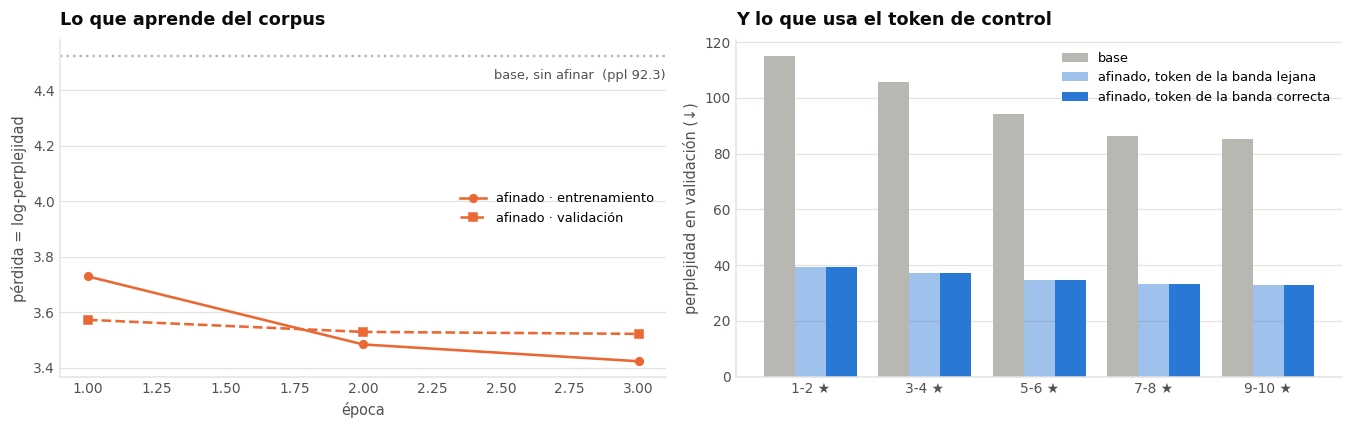

In [21]:
def curva(historial, clave):
    xs, ys = [], []
    for e in historial:
        if clave in e and "epoch" in e:
            xs.append(e["epoch"]); ys.append(e[clave])
    return xs, ys

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.0))

for clave, estilo, etq in [("loss", "o-", "entrenamiento"), ("eval_loss", "s--", "validación")]:
    xs, ys = curva(historial_lm, clave)
    ax1.plot(xs, ys, estilo, color=NARANJA, lw=1.7, ms=5, label=f"afinado · {etq}")
ax1.axhline(math.log(PPL_BASE), color=GRIS_REAL, lw=1.6, ls=":")
ax1.text(ax1.get_xlim()[1], math.log(PPL_BASE) - .05, f"base, sin afinar  (ppl {PPL_BASE:.1f})",
         ha="right", va="top", fontsize=8.5, color=TINTA_2)
ax1.set_xlabel("época"); ax1.set_ylabel("pérdida = log-perplejidad")
ax1.set_title("Lo que aprende del corpus")
ax1.legend(fontsize=8.5); ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

x = np.arange(N_CLASES); ancho = .27
ax2.bar(x - ancho, tabla_ppl["base"], ancho, color=GRIS_REAL, label="base")
ax2.bar(x, tabla_ppl["afinado · lejana"], ancho, color=AZUL, alpha=.45,
        label="afinado, token de la banda lejana")
ax2.bar(x + ancho, tabla_ppl["afinado · correcta"], ancho, color=AZUL,
        label="afinado, token de la banda correcta")
ax2.set_xticks(x); ax2.set_xticklabels([f"{b} ★" for b in BANDAS])
ax2.set_ylabel("perplejidad en validación (↓)")
ax2.set_title("Y lo que usa el token de control")
ax2.legend(fontsize=8.5, loc="upper right")
ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "02-perplejidad"); plt.show()

**El modelo aprendió el corpus.** La perplejidad baja de **92,3 a 34,4**. La pérdida de validación baja
en las tres épocas (3,57, 3,53 y 3,52) sin empezar a subir, así que no hay sobreajuste, aunque la
mejora ya es pequeña en la tercera.

**Pero no usa el token de control.** Con el token correcto la perplejidad es 34,42 y con el de la banda
opuesta 34,43. En el panel derecho las dos barras azules de cada banda tienen la misma altura. El
modelo escribe igual sin importar la nota que le pidamos. Esto ya anticipa todo lo de §7.

La causa la encontramos después de la corrida. En GPT-2, el estado oculto de la **primera posición**
toma valores enormes en unas pocas dimensiones, sea cual sea el token que haya ahí, y el modelo usa esa
posición como un lugar donde descargar atención sobrante (*attention sink*; Xiao *et al.*, 2024; Sun
*et al.*, 2024). Lo que identifica al token se pierde. Nosotros pusimos el token de control justo en esa
posición.

Para comprobarlo hicimos dos *fine-tunings* cortos e iguales en todo, salvo por un `<|endoftext|>`
delante del token de control, que así queda en la posición 1. Usamos 4.000 críticas, una época y 400
de validación (script `diagnostico_posicion0.py`, en esta carpeta):

| Dónde va el token de control | ppl con banda correcta | ppl con banda lejana | acierto por Bayes |
|---|---|---|---|
| posición 0 (como en este notebook) | 43,505 | 43,505 | 0,188 |
| posición 1, después de `<|endoftext|>` | 41,052 | 41,069 | 0,235 |

En la posición 0 las dos perplejidades son iguales hasta el tercer decimal: el modelo no puede ver qué
token hay ahí. En la posición 1 la información sí llega. Con tan poco entrenamiento el efecto todavía
es pequeño, pero existe.

La prueba de humo ya mostraba las dos perplejidades iguales (68,68 contra 68,67). Lo atribuimos a
que con 400 críticas y una época no daba tiempo a aprender nada, y no lo revisamos más.

### 6.4 El siguiente token, banda por banda

El experimento de §3.3 con el modelo afinado: el mismo comienzo, *"La película es"*, con cada uno de
los cinco tokens de control delante.

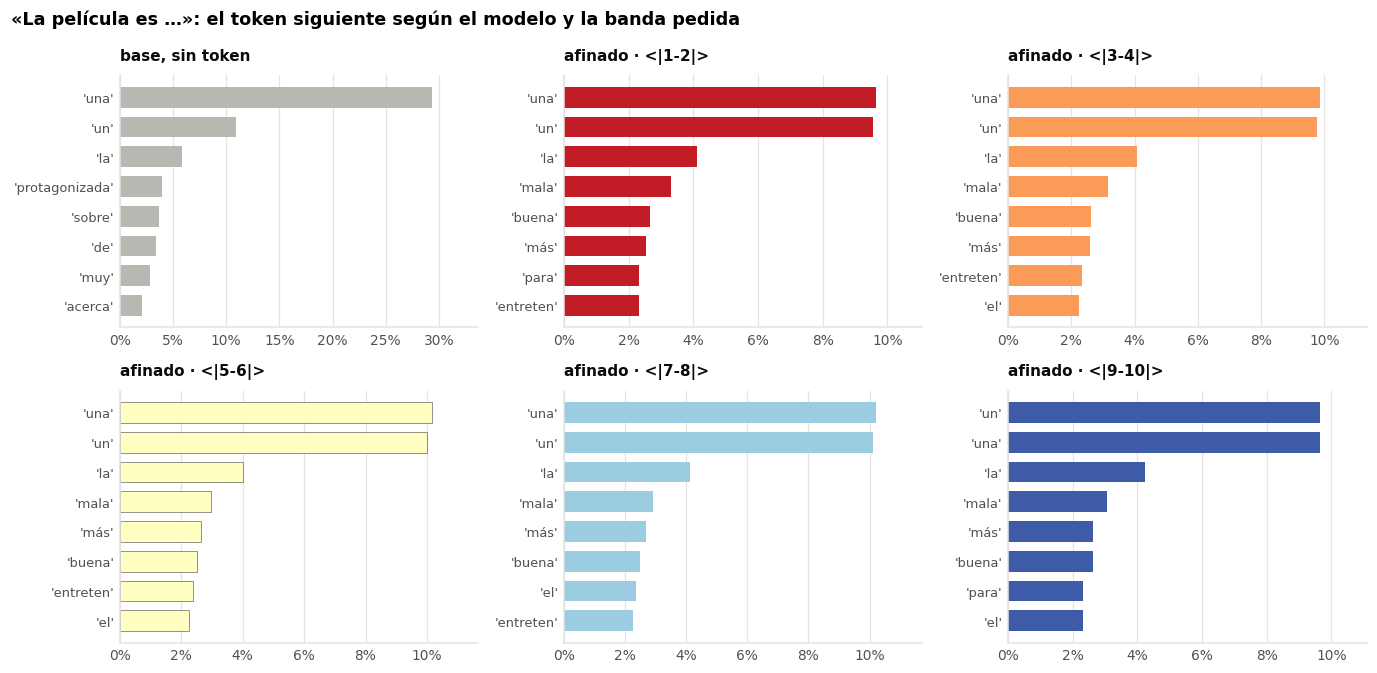

In [22]:
fig, ejes = plt.subplots(2, 3, figsize=(12.6, 6.2))
ejes = ejes.ravel()
TOP_SIG = 8

paneles = [("base, sin token", gpt_base, ids_inicio, GRIS_REAL)] + \
          [(f"afinado · {CTRL[k]}", gpt, [CTRL_ID[k]] + ids_inicio, COLOR_BANDA[k])
           for k in ETIQUETAS]
for ax, (titulo, modelo, ids, color) in zip(ejes, paneles):
    dist = siguiente_token(modelo, ids, top=TOP_SIG)[::-1]
    ax.barh(range(len(dist)), [p for _, p in dist], color=color, height=.7,
            edgecolor=TINTA_2 if color == COLOR_BANDA[2] else "none", lw=.4)
    ax.set_yticks(range(len(dist)))
    ax.set_yticklabels([repr(t.strip() or t) for t, _ in dist], fontsize=8.5)
    ax.set_title(titulo, fontsize=10)
    ax.set_xlim(0, max(.05, max(p for _, p in dist) * 1.15))
    ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
    ax.grid(axis="x"); ax.set_axisbelow(True); limpiar(ax)
fig.suptitle(f"«{INICIO} …»: el token siguiente según el modelo y la banda pedida",
             x=.01, ha="left", fontsize=11.5, fontweight="bold")
plt.tight_layout(); guardar(fig, "03-siguiente-token"); plt.show()

Hay dos cosas en la figura. Comparado con el base, el modelo afinado ya habla como crítico: entre los
primeros candidatos aparecen *mala*, *buena*, *más* y *entreten…*, y desaparecen *protagonizada* y
*dirigida*. Pero los cinco paneles afinados son casi idénticos. Con `<|1-2|>` y con `<|9-10|>`, *mala*
tiene la misma probabilidad (alrededor del 3%). Es la misma conclusión de §6.3, vista de otra forma.

---

## 7. ¿Escribe la nota que se le pide?

### 7.1 Generar y juzgar

`generar_conjunto()` produce `N_GEN` críticas por banda con una configuración de decodificación, y las
guarda en `resultados/generaciones_s4.parquet`. Si el notebook se interrumpe, lo ya generado no se
repite.

Primero las tres condiciones de H1, todas con la configuración principal de §4:

| Condición | Modelo | *Prompt* |
|---|---|---|
| `base · nota` | GPT-2 sin afinar | *"Mi crítica de esta película. Le pongo un 2 sobre 10."* |
| `base · adjetivo` | GPT-2 sin afinar | *"Mi crítica de una película pésima."* |
| `afinado · top-p 0.90` | GPT-2 afinado | solo el token de control |

Al juez le damos solo lo que escribió el modelo, nunca el *prompt*. Si leyera *"Le pongo un 2"*,
acertaría por nuestra instrucción y no por el texto generado.

In [23]:
CACHE_GEN = RES / "generaciones_s4.parquet"
# Si se reentrenó el generador, lo generado con el anterior ya no vale.
GENERACIONES = (pd.read_parquet(CACHE_GEN) if CACHE_GEN.exists() and not REENTRENAR
                else pd.DataFrame())

DECODIFICACIONES = {
    "T 0.3":            dict(do_sample=True, temperature=0.3, top_k=0, top_p=1.0),
    "T 0.5":            dict(do_sample=True, temperature=0.5, top_k=0, top_p=1.0),
    "T 0.7":            dict(do_sample=True, temperature=0.7, top_k=0, top_p=1.0),
    "T 1.0":            dict(do_sample=True, temperature=1.0, top_k=0, top_p=1.0),
    "T 1.3":            dict(do_sample=True, temperature=1.3, top_k=0, top_p=1.0),
    "top-k 50":         dict(do_sample=True, temperature=1.0, top_k=50, top_p=1.0),
    "top-p 0.90":       dict(do_sample=True, temperature=1.0, top_k=0, top_p=0.90),
    "top-p 0.90 · rep 1.2": dict(do_sample=True, temperature=1.0, top_k=0, top_p=0.90,
                                 repetition_penalty=1.2),
}
PRINCIPAL = "top-p 0.90"
BARRIDO_T = ["T 0.3", "T 0.5", "T 0.7", "T 1.0", "T 1.3"]


@torch.no_grad()
def generar_lote(modelo, prompt_ids, n, semilla, lote=50, **cfg):
    # n continuaciones de un mismo prompt. Devuelve [(texto, terminó_sola, n_tokens)].
    torch.manual_seed(semilla)
    salida = []
    for i in range(0, n, lote):
        m = min(lote, n - i)
        x = torch.tensor([prompt_ids] * m, device=DEVICE)
        g = modelo.generate(input_ids=x, attention_mask=torch.ones_like(x),
                            max_new_tokens=MAX_NUEVOS, pad_token_id=PAD_ID,
                            eos_token_id=EOS_ID, **cfg)[:, len(prompt_ids):].tolist()
        for fila in g:
            termino = EOS_ID in fila
            fila = fila[:fila.index(EOS_ID)] if termino else fila
            fila = [t for t in fila if t != PAD_ID]
            salida.append((tok.decode(fila, skip_special_tokens=True).strip(), termino, len(fila)))
    return salida


def generar_conjunto(nombre_modelo, config, prompts_ids, modelo, n=N_GEN, cfg=None):
    # Genera (o recupera de la caché) n críticas por banda para un modelo y una configuración.
    global GENERACIONES
    if len(GENERACIONES):
        hecho = GENERACIONES[(GENERACIONES.modelo == nombre_modelo) &
                             (GENERACIONES.config == config)]
        if len(hecho) == n * N_CLASES:
            return hecho.reset_index(drop=True)
    cfg = cfg if cfg is not None else DECODIFICACIONES[config]
    filas = []
    for k in ETIQUETAS:
        for texto, termino, ntk in generar_lote(modelo, prompts_ids[k], n, semilla=SEED + k, **cfg):
            filas.append({"modelo": nombre_modelo, "config": config, "banda": k,
                          "texto": texto, "termino": termino, "n_tokens": ntk})
    nuevo = pd.DataFrame(filas)
    if len(GENERACIONES):
        GENERACIONES = GENERACIONES[~((GENERACIONES.modelo == nombre_modelo) &
                                      (GENERACIONES.config == config))]
    GENERACIONES = pd.concat([GENERACIONES, nuevo], ignore_index=True)
    GENERACIONES.to_parquet(CACHE_GEN, index=False)
    return nuevo


PROMPTS_AFINADO = [[c] for c in CTRL_ID]
with medir("§7.1 generación de las condiciones de H1"):
    conjuntos = {}
    for nombre, prompts in PROMPTS_BASE.items():
        conjuntos[nombre] = generar_conjunto(nombre, PRINCIPAL,
                                             [tok(p)["input_ids"] for p in prompts], gpt_base)
    conjuntos[f"afinado · {PRINCIPAL}"] = generar_conjunto("afinado", PRINCIPAL,
                                                           PROMPTS_AFINADO, gpt)
for nombre, d in conjuntos.items():
    print(f"{nombre:<24} {len(d):>4} críticas   terminan solas {d.termino.mean():6.1%}   "
          f"longitud media {d.n_tokens.mean():5.0f} tokens   vacías {(d.texto.str.len() == 0).sum()}")

   ⏱  §7.1 generación de las condiciones de H1: 2.1 min   (acumulado 51.5 min)
base · nota               500 críticas   terminan solas   0.0%   longitud media   200 tokens   vacías 0
base · adjetivo           500 críticas   terminan solas   0.0%   longitud media   200 tokens   vacías 0
afinado · top-p 0.90      500 críticas   terminan solas  36.8%   longitud media   168 tokens   vacías 0


El arreglo del fin de texto funcionó: el 37% de las críticas del modelo afinado terminan solas, antes
de los 200 tokens, y miden 168 tokens en promedio. El modelo base no termina ninguna, porque no tiene
cómo.

Ahora pasamos los textos por el juez. `medir_control()` aplica los dos jueces y mide la diversidad de
dos maneras:

- ***distinct-2***: pares de palabras distintos sobre el total, dentro de cada banda. Si las 100
  críticas de una banda repiten las mismas frases, baja.
- **repetición**: proporción de 4-gramas repetidos dentro de una misma crítica. Mide los bucles de la
  decodificación voraz.

In [24]:
PALABRA = re.compile(r"\w+", re.UNICODE)

def palabras(t):
    return PALABRA.findall(t.lower())

def ngramas(ws, n):
    return [tuple(ws[i:i + n]) for i in range(len(ws) - n + 1)]

def distinct2(textos):
    todos = [g for t in textos for g in ngramas(palabras(t), 2)]
    return len(set(todos)) / max(len(todos), 1)

def repeticion4(t):
    g = ngramas(palabras(t), 4)
    return 1 - len(set(g)) / len(g) if g else 0.0

FILAS_CONTROL = []

def medir_control(nombre, d, verbose=False):
    # Juzga un conjunto generado y devuelve (fila de métricas, conjunto con las columnas del juez).
    d = d.copy()
    pred, P = juzgar_beto(list(d.texto))
    d["juez_beto"] = pred
    d["p_pedida"] = P[np.arange(len(d)), d.banda.values]
    d["juez_tfidf"] = juzgar_tfidf(d.texto)
    m = evaluar(d.banda, d.juez_beto, nombre=f"control · {nombre}", particion="generadas",
                notas=f"{len(d)} críticas, juez BETO", verbose=verbose)
    m_tf = evaluar(d.banda, d.juez_tfidf, nombre=f"control · {nombre} (TF-IDF)",
                   particion="generadas", notas=f"{len(d)} críticas, juez TF-IDF", verbose=False)
    fila = {"condición": nombre,
            "QWK": m["qwk"], "± QWK": ruido(d.banda, d.juez_beto, qwk),
            "macro-F1": m["macro_f1"], "± F1": ruido(d.banda, d.juez_beto, macro_f1),
            "QWK TF-IDF": m_tf["qwk"],
            "distinct-2": np.mean([distinct2(d[d.banda == k].texto) for k in ETIQUETAS]),
            "repetición": d.texto.map(repeticion4).mean(),
            "terminan": d.termino.mean() if "termino" in d else np.nan,
            "palabras": d.texto.map(lambda t: len(palabras(t))).mean()}
    FILAS_CONTROL.append(fila)
    return fila, m, d

fila_r = {"condición": "reales (techo)", "QWK": techo["qwk"], "± QWK": SD_TECHO_QWK,
          "macro-F1": techo["macro_f1"], "± F1": SD_TECHO_F1, "QWK TF-IDF": techo_tf["qwk"],
          "distinct-2": np.mean([distinct2(reales[reales.banda == k].texto) for k in ETIQUETAS]),
          "repetición": reales.texto.map(repeticion4).mean(), "terminan": 1.0,
          "palabras": reales.texto.map(lambda t: len(palabras(t))).mean()}
FILAS_CONTROL.append(fila_r)

juzgados, metricas = {}, {}
for nombre, d in conjuntos.items():
    _, metricas[nombre], juzgados[nombre] = medir_control(nombre, d,
                                                          verbose=nombre.startswith("afinado"))

tabla_h1 = pd.DataFrame(FILAS_CONTROL)
print(tabla_h1.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

── control · afinado · top-p 0.90  (generadas)
   macro-F1 0.1958   accuracy 0.2140   QWK 0.0535   MAE 1.4260   adyacente 0.5620

              precision    recall  f1-score   support

         1-2      0.241     0.070     0.109       100
         3-4      0.180     0.090     0.120       100
         5-6      0.217     0.330     0.262       100
         7-8      0.198     0.370     0.258       100
        9-10      0.256     0.210     0.231       100

    accuracy                          0.214       500
   macro avg      0.218     0.214     0.196       500
weighted avg      0.218     0.214     0.196       500

           condición    QWK  ± QWK  macro-F1  ± F1  QWK TF-IDF  distinct-2  repetición  terminan  palabras
      reales (techo)  0.775  0.023     0.529 0.022       0.676       0.724       0.003     1.000   243.630
         base · nota -0.038  0.044     0.178 0.017       0.024       0.749       0.014     0.000   133.314
     base · adjetivo  0.111  0.044     0.197 0.018       0.0

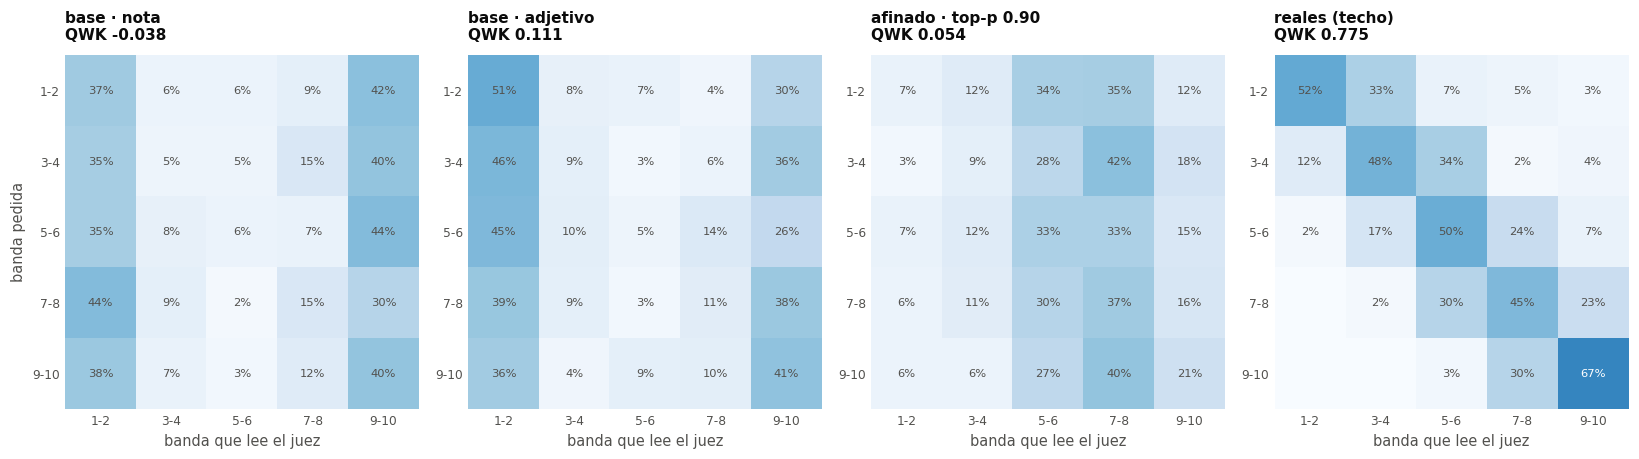

H1 · mejor QWK del modelo base : +0.1115   (criterio: < 0,20)
H1 · QWK del afinado            : +0.0535   (criterio: ≥ 0,50)


In [25]:
NOMBRE_PRINCIPAL = f"afinado · {PRINCIPAL}"
paneles = [("base · nota", metricas["base · nota"]["confusion"]),
           ("base · adjetivo", metricas["base · adjetivo"]["confusion"]),
           (NOMBRE_PRINCIPAL, metricas[NOMBRE_PRINCIPAL]["confusion"]),
           ("reales (techo)", techo["confusion"])]

fig, ejes = plt.subplots(1, 4, figsize=(15.0, 3.9))
for ax, (titulo, cm) in zip(ejes, paneles):
    filas_norm = cm / np.maximum(cm.sum(1, keepdims=True), 1)
    ax.imshow(filas_norm, cmap="Blues", vmin=0, vmax=1)
    for i in range(N_CLASES):
        for j in range(N_CLASES):
            v = filas_norm[i, j]
            ax.text(j, i, f"{v:.0%}" if v >= .005 else "", ha="center", va="center",
                    fontsize=7.5, color="white" if v > .55 else TINTA_2)
    ax.set_xticks(ETIQUETAS); ax.set_xticklabels(BANDAS, fontsize=8)
    ax.set_yticks(ETIQUETAS); ax.set_yticklabels(BANDAS, fontsize=8)
    ax.set_xlabel("banda que lee el juez")
    q = tabla_h1.set_index("condición").loc[titulo, "QWK"]
    ax.set_title(f"{titulo}\nQWK {q:.3f}", fontsize=10)
    for s in ax.spines.values():
        s.set_visible(False)
ejes[0].set_ylabel("banda pedida")
plt.tight_layout(); guardar(fig, "04-pedida-vs-juzgada"); plt.show()

QWK_BASE = max(metricas["base · nota"]["qwk"], metricas["base · adjetivo"]["qwk"])
QWK_AFINADO = metricas[NOMBRE_PRINCIPAL]["qwk"]
print(f"H1 · mejor QWK del modelo base : {QWK_BASE:+.4f}   (criterio: < 0,20)")
print(f"H1 · QWK del afinado            : {QWK_AFINADO:+.4f}   (criterio: ≥ 0,50)")

**H1 se cumple solo a medias, y no por la razón que esperábamos.** El modelo base no obedece: QWK de
−0,038 pidiéndole el número y de 0,111 pidiéndole el adjetivo. Pero el afinado tampoco: 0,054, muy
lejos del 0,50 del criterio y del techo de 0,775.

Las matrices muestran dos fallas distintas. El base escribe textos que no parecen críticas, y el juez
los manda a los extremos: casi todo cae en `1-2` o en `9-10`, sin importar la banda pedida. Con el
adjetivo hay algo de señal, porque "pésima" da 51% de `1-2`, pero "excelente" también da 36% de `1-2`.
El afinado escribe críticas que sí parecen reales, pero siempre de nota media: en todas las filas el
juez lee sobre todo `5-6` y `7-8`. Es lo que se espera si el token se ignora, porque el modelo escribe
una crítica promedio del corpus.

Curiosamente, pedirle la nota al modelo base con un adjetivo da un poco más de control que nuestro
token. Eso no dice que el *prompt* funcione; dice que el token no funcionó.

### 7.2 ¿Caricaturas?

H2 compara al juez con las críticas generadas y con las reales, con el mismo número de textos por
banda. También miramos la probabilidad que el juez le da a la banda pedida: si el generador escribe
caricaturas, el juez debería acertar más y con más seguridad. Y lo comprobamos con el TF-IDF, para que
no sea un efecto de BETO.

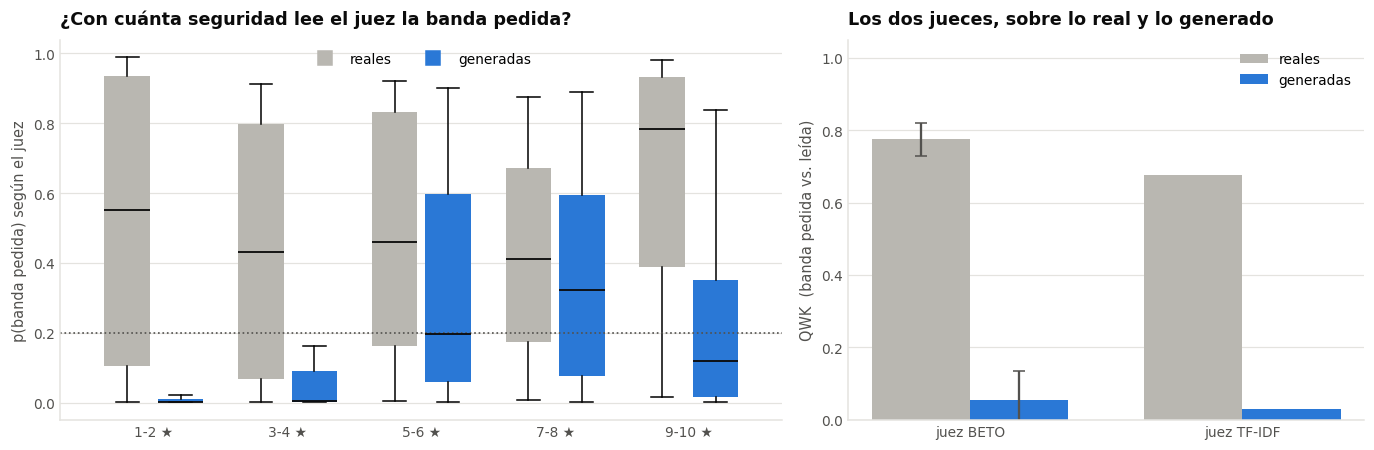

H2 · QWK generadas − reales (BETO)   : -0.7216   umbral de ruido 0.0925
     QWK generadas − reales (TF-IDF) : -0.6462
     p(banda pedida), mediana        : generadas 0.063   reales 0.511


In [26]:
gen_p = juzgados[NOMBRE_PRINCIPAL]
fila_p = tabla_h1.set_index("condición").loc[NOMBRE_PRINCIPAL]
UMBRAL_H2 = umbral(fila_p["± QWK"], SD_TECHO_QWK)
DELTA_H2 = fila_p["QWK"] - techo["qwk"]
DELTA_H2_TF = fila_p["QWK TF-IDF"] - techo_tf["qwk"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.2), gridspec_kw={"width_ratios": [1.4, 1]})

pos = np.arange(N_CLASES)
for desp, datos, color, etq in [(-.2, reales, GRIS_REAL, "reales"),
                                (+.2, gen_p, AZUL, "generadas")]:
    cajas = [datos[datos.banda == k].p_pedida.values for k in ETIQUETAS]
    bp = ax1.boxplot(cajas, positions=pos + desp, widths=.34, patch_artist=True,
                     showfliers=False, medianprops={"color": TINTA, "lw": 1.2})
    for caja in bp["boxes"]:
        caja.set_facecolor(color); caja.set_edgecolor("none")
    ax1.plot([], [], "s", color=color, ms=9, label=etq)
ax1.axhline(1 / N_CLASES, color=TINTA_2, ls=":", lw=1.1)
ax1.set_xticks(pos); ax1.set_xticklabels([f"{b} ★" for b in BANDAS])
ax1.set_ylabel("p(banda pedida) según el juez")
ax1.set_title("¿Con cuánta seguridad lee el juez la banda pedida?")
ax1.legend(loc="upper center", ncol=2)
ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

x = np.arange(2); ancho = .36
ax2.bar(x - ancho/2, [techo["qwk"], techo_tf["qwk"]], ancho, color=GRIS_REAL, label="reales")
ax2.bar(x + ancho/2, [fila_p["QWK"], fila_p["QWK TF-IDF"]], ancho, color=AZUL, label="generadas")
ax2.errorbar(x[:1] - ancho/2, [techo["qwk"]], yerr=[2 * SD_TECHO_QWK], fmt="none",
             ecolor=TINTA_2, capsize=4)
ax2.errorbar(x[:1] + ancho/2, [fila_p["QWK"]], yerr=[2 * fila_p["± QWK"]], fmt="none",
             ecolor=TINTA_2, capsize=4)
ax2.set_xticks(x); ax2.set_xticklabels(["juez BETO", "juez TF-IDF"])
ax2.set_ylabel("QWK  (banda pedida vs. leída)")
ax2.set_ylim(0, 1.05)
ax2.set_title("Los dos jueces, sobre lo real y lo generado")
ax2.legend(loc="upper right")
ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "05-caricatura"); plt.show()

print(f"H2 · QWK generadas − reales (BETO)   : {DELTA_H2:+.4f}   umbral de ruido {UMBRAL_H2:.4f}")
print(f"     QWK generadas − reales (TF-IDF) : {DELTA_H2_TF:+.4f}")
print(f"     p(banda pedida), mediana        : generadas {gen_p.p_pedida.median():.3f}   "
      f"reales {reales.p_pedida.median():.3f}")

**H2 se refuta, pero la pregunta no llegó a probarse.** El juez acierta mucho menos con las generadas
que con las reales (QWK 0,054 contra 0,775), y la probabilidad mediana que le da a la banda pedida es
0,06, contra 0,51 en las reales. El TF-IDF dice lo mismo. Para saber si el modelo exagera, primero
tendría que escribir bandas distintas, y no lo hace.

### 7.3 ¿Qué bandas se dejan escribir?

H3 aplica a la generación lo que vimos en la Sesión 3 al clasificar: la banda `3-4` era la más difícil,
porque está entre otras dos y no tiene palabras propias.

In [27]:
cm_g = metricas[NOMBRE_PRINCIPAL]["confusion"]
recall_gen  = np.diag(cm_g) / np.maximum(cm_g.sum(1), 1)
recall_real = np.diag(techo["confusion"]) / np.maximum(techo["confusion"].sum(1), 1)
EXTREMOS, MEDIO = [0, 4], [1, 2, 3]
BRECHA_H3 = recall_gen[EXTREMOS].mean() - recall_gen[MEDIO].mean()

tabla_rec = pd.DataFrame({"banda": BANDAS, "recall generadas": recall_gen,
                          "recall reales": recall_real})
print(tabla_rec.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\nH3 · recall extremos − recall medio (generadas): {BRECHA_H3:+.4f}   (criterio: > 0,15)")
print(f"     lo mismo sobre reales                     : "
      f"{recall_real[EXTREMOS].mean() - recall_real[MEDIO].mean():+.4f}")

banda  recall generadas  recall reales
  1-2             0.070          0.520
  3-4             0.090          0.480
  5-6             0.330          0.500
  7-8             0.370          0.450
 9-10             0.210          0.670

H3 · recall extremos − recall medio (generadas): -0.1233   (criterio: > 0,15)
     lo mismo sobre reales                     : +0.1183


**H3 se refuta por el mismo motivo.** En las generadas, las bandas con más *recall* son `5-6` (0,33) y
`7-8` (0,37), y los extremos casi no se aciertan (0,07 y 0,21). No es que el modelo escriba mejor la
nota media: escribe siempre una crítica media, y por eso acierta cuando se le pide una nota media. En
las reales el patrón es el esperado: los extremos se leen mejor que el medio (+0,12).

### 7.4 La decodificación: diversidad contra control

El guía presenta la decodificación como un equilibrio entre explorar y aprovechar, pero no lo mide.
Aquí podemos medirlo: el control lo da el juez y la diversidad el *distinct-2*.

Probamos cinco temperaturas sin otro filtro, que es lo que pide H4, y tres configuraciones comunes:
*top-k*, *top-p* y *top-p* con penalización de repetición. La decodificación voraz va aparte, con una
crítica por banda, porque es determinista y cien serían la misma repetida cien veces.

In [28]:
with medir("§7.4 barrido de decodificación"):
    for config in DECODIFICACIONES:
        if config == PRINCIPAL:
            continue
        d = generar_conjunto("afinado", config, PROMPTS_AFINADO, gpt)
        _, metricas[f"afinado · {config}"], juzgados[f"afinado · {config}"] = \
            medir_control(f"afinado · {config}", d)

tabla_dec = pd.DataFrame(FILAS_CONTROL).drop_duplicates("condición", keep="last")
afinadas = tabla_dec[tabla_dec["condición"].str.startswith("afinado")].copy()
afinadas["config"] = afinadas["condición"].str.replace("afinado · ", "", regex=False)
print(afinadas.drop(columns="condición").set_index("config")
      .to_string(float_format=lambda v: f"{v:.3f}"))

voraz = []
for k in ETIQUETAS:
    ids_g, _ = generar(gpt, [CTRL_ID[k]], max_nuevos=MAX_NUEVOS, eps=1.0)
    voraz.append(tok.decode([t for t in ids_g if t != EOS_ID]))
print("\nVoraz, una por banda (repetición dentro de la crítica):")
for k, t in enumerate(voraz):
    print(f"   {BANDAS[k]:>5}  rep {repeticion4(t):.2f}   {t[:110]!r}")

   ⏱  §7.4 barrido de decodificación: 4.1 min   (acumulado 55.6 min)
                        QWK  ± QWK  macro-F1  ± F1  QWK TF-IDF  distinct-2  repetición  terminan  palabras
config                                                                                                    
top-p 0.90            0.054  0.040     0.196 0.018       0.030       0.712       0.005     0.368   129.508
T 0.3                -0.002  0.025     0.155 0.016      -0.025       0.087       0.747     0.082   147.616
T 0.5                 0.029  0.030     0.161 0.015      -0.025       0.240       0.409     0.302   140.554
T 0.7                -0.040  0.034     0.156 0.016      -0.001       0.488       0.077     0.408   131.768
T 1.0                 0.042  0.044     0.208 0.019      -0.011       0.801       0.001     0.288   131.754
T 1.3                 0.006  0.043     0.195 0.018      -0.001       0.985       0.000     0.102   111.978
top-k 50             -0.066  0.039     0.179 0.016      -0.029       0.609 

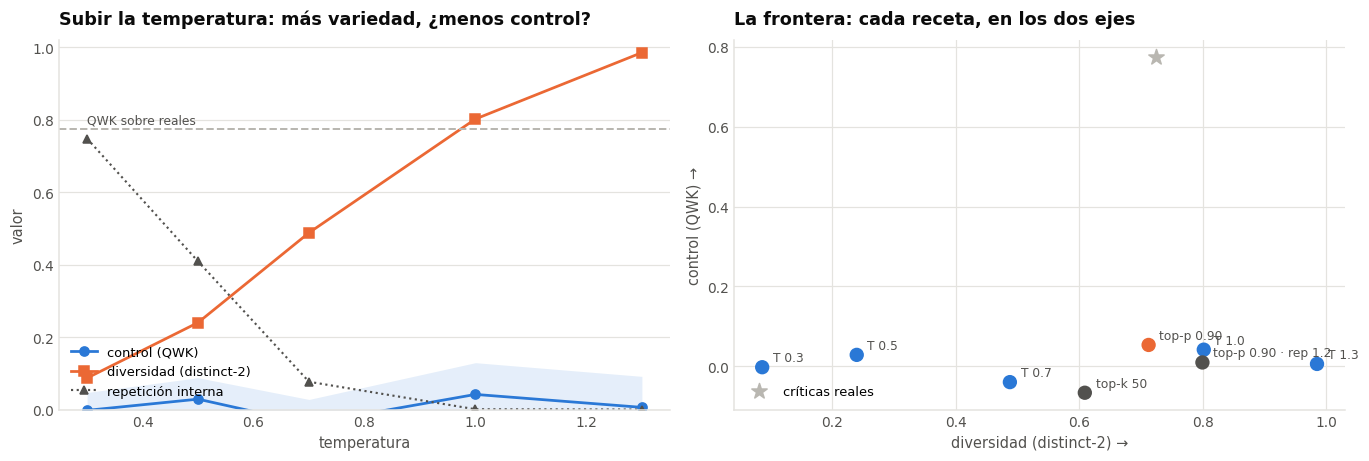

H4 · ρ(temperatura, distinct-2) = +1.00   (criterio: ≥ +0,8)
     ρ(temperatura, QWK)        = +0.30   (criterio: ≤ −0,8)


In [29]:
from scipy.stats import spearmanr

barrido = afinadas.set_index("config").loc[BARRIDO_T]
temps = [DECODIFICACIONES[c]["temperature"] for c in BARRIDO_T]
RHO_T_DIV = float(spearmanr(temps, barrido["distinct-2"]).statistic)
RHO_T_QWK = float(spearmanr(temps, barrido["QWK"]).statistic)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.3))

ax1.plot(temps, barrido["QWK"], "o-", color=AZUL, lw=1.8, ms=6, label="control (QWK)")
ax1.fill_between(temps, barrido["QWK"] - 2 * barrido["± QWK"],
                 barrido["QWK"] + 2 * barrido["± QWK"], color=AZUL, alpha=.12, lw=0)
ax1.plot(temps, barrido["distinct-2"], "s-", color=NARANJA, lw=1.8, ms=6,
         label="diversidad (distinct-2)")
ax1.plot(temps, barrido["repetición"], "^:", color=TINTA_2, lw=1.4, ms=5,
         label="repetición interna")
ax1.axhline(techo["qwk"], color=GRIS_REAL, ls="--", lw=1.3)
ax1.text(temps[0], techo["qwk"] + .015, "QWK sobre reales", fontsize=8, color=TINTA_2)
ax1.set_xlabel("temperatura"); ax1.set_ylabel("valor")
ax1.set_ylim(0, 1.02)
ax1.set_title("Subir la temperatura: más variedad, ¿menos control?")
ax1.legend(fontsize=8.5, loc="lower left")
ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

colores = [NARANJA if c == PRINCIPAL else (AZUL if c.startswith("T ") else TINTA_2)
           for c in afinadas.config]
ax2.scatter(afinadas["distinct-2"], afinadas["QWK"], s=70, color=colores, zorder=3)
for c, dx, q in zip(afinadas.config, afinadas["distinct-2"], afinadas["QWK"]):
    ax2.annotate(c, (dx, q), textcoords="offset points", xytext=(7, 4), fontsize=8, color=TINTA_2)
ax2.scatter([fila_r["distinct-2"]], [techo["qwk"]], s=110, marker="*", color=GRIS_REAL,
            zorder=3, label="críticas reales")
ax2.set_xlabel("diversidad (distinct-2) →")
ax2.set_ylabel("control (QWK) →")
ax2.set_title("La frontera: cada receta, en los dos ejes")
ax2.legend(fontsize=8.5, loc="lower left")
ax2.grid(True); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "06-decodificacion"); plt.show()
print(f"H4 · ρ(temperatura, distinct-2) = {RHO_T_DIV:+.2f}   (criterio: ≥ +0,8)")
print(f"     ρ(temperatura, QWK)        = {RHO_T_QWK:+.2f}   (criterio: ≤ −0,8)")

**La diversidad se comporta como se esperaba.** Al subir la temperatura de 0,3 a 1,3, el *distinct-2*
sube de 0,09 a 0,99 y la repetición interna baja de 0,75 a 0. Con temperatura baja el modelo cae en
bucles; con temperatura alta inventa palabras. Las críticas reales tienen un *distinct-2* de 0,72, y
*top-p* 0,90 (0,71) es la configuración que más se les parece.

**El control no cambia con nada.** El QWK se queda entre −0,07 y 0,05 en todas las configuraciones,
dentro del ruido. Por eso H4 sale a medias: la mitad de la diversidad se cumple (ρ = +1,00), pero no hay
control que perder (ρ = +0,30). En el panel derecho todas las configuraciones quedan en una franja
cerca de cero, muy abajo de la estrella de las críticas reales.

La prueba más directa de que el token se ignora está en la decodificación voraz: el modelo escribe
**exactamente la misma crítica para las cinco bandas**, *"La vida es un juego"* repetida en bucle.

*top-p* con penalización de repetición hace que el 51% de las críticas terminen solas, el valor más alto.
Sirve para la calidad del texto, aunque no para el control.

### 7.5 ¿Copia?

Un modelo de 124 millones de parámetros entrenado con 12.000 críticas podría memorizarlas. Medimos qué
proporción de los 8-gramas de cada crítica generada aparece tal cual en el entrenamiento. La referencia
son las críticas reales de validación, que el modelo no vio y que también comparten algunas frases
hechas con el entrenamiento.

   ⏱  §7.5 índice de 8-gramas de entrenamiento: 0.1 min   (acumulado 55.6 min)
índice: 2,796,310 8-gramas distintos en entrenamiento

            conjunto  8-gramas copiados (media)  críticas con algún 8-grama copiado  críticas copiadas en más de la mitad
 reales (validación)                      0.001                               0.098                                 0.000
afinado · top-p 0.90                      0.000                               0.022                                 0.000
     afinado · T 0.3                      0.028                               0.274                                 0.000
     afinado · T 1.3                      0.000                               0.000                                 0.000


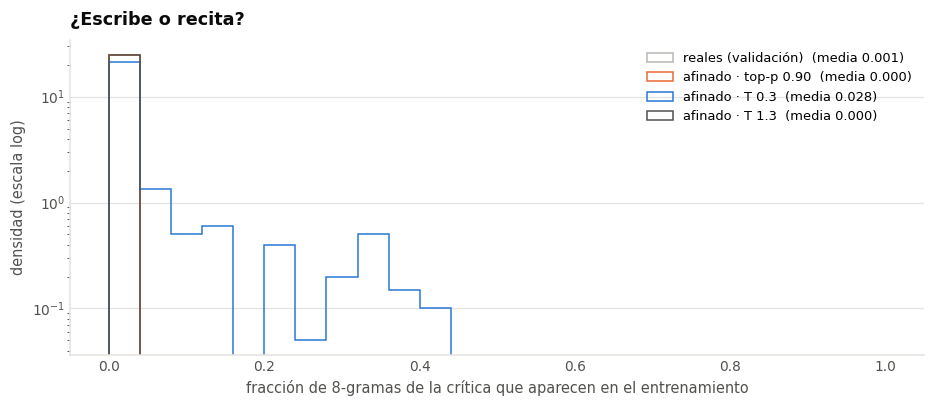

In [30]:
N_COPIA = 8
with medir("§7.5 índice de 8-gramas de entrenamiento"):
    INDICE = {hash(g) for t in df_train.texto for g in ngramas(palabras(t), N_COPIA)}

def solapamiento(t):
    g = ngramas(palabras(t), N_COPIA)
    return sum(hash(x) in INDICE for x in g) / len(g) if g else 0.0

reales["copia"] = reales.texto.map(solapamiento)
copias = {"reales (validación)": reales.copia.values}
for nombre in [NOMBRE_PRINCIPAL] + [f"afinado · {c}" for c in ("T 0.3", "T 1.3")]:
    juzgados[nombre]["copia"] = juzgados[nombre].texto.map(solapamiento)
    copias[nombre] = juzgados[nombre].copia.values

tabla_copia = pd.DataFrame([
    {"conjunto": n, "8-gramas copiados (media)": v.mean(),
     "críticas con algún 8-grama copiado": float(np.mean(v > 0)),
     "críticas copiadas en más de la mitad": float(np.mean(v > .5))}
    for n, v in copias.items()])
print(f"índice: {len(INDICE):,} 8-gramas distintos en entrenamiento\n")
print(tabla_copia.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

COPIA_GEN = copias[NOMBRE_PRINCIPAL].mean()
COPIA_REAL = copias["reales (validación)"].mean()

fig, ax = plt.subplots(figsize=(8.6, 3.8))
colores = [GRIS_REAL, NARANJA, AZUL, TINTA_2]
for (n, v), c in zip(copias.items(), colores):
    ax.hist(np.clip(v, 0, 1), bins=np.linspace(0, 1, 26), histtype="step", lw=1.8, color=c,
            label=f"{n}  (media {v.mean():.3f})", density=True)
ax.set_yscale("log")
ax.set_xlabel("fracción de 8-gramas de la crítica que aparecen en el entrenamiento")
ax.set_ylabel("densidad (escala log)")
ax.set_title("¿Escribe o recita?")
ax.legend(fontsize=8.5)
ax.grid(axis="y"); ax.set_axisbelow(True); limpiar(ax)
plt.tight_layout(); guardar(fig, "07-copia"); plt.show()

if COPIA_GEN > 3 * max(COPIA_REAL, 1e-3):
    print(f"\n⚠ El generador copia {COPIA_GEN/max(COPIA_REAL,1e-3):.1f}× más que la referencia: "
          "el control de §7.1 puede estar inflado por memorización.")

**No copia.** Con la configuración principal, el 2% de las críticas tiene algún 8-grama del
entrenamiento, menos que las reales de validación (10%). La excepción es la temperatura 0,3: el 27% de
sus críticas repite alguna frase hecha, porque elige siempre lo más probable. Aun así, ninguna crítica
generada copia más de la mitad de su texto.

---

## 8. El generador como clasificador

### 8.1 La regla de Bayes

Si el GPT-2 afinado sabe calcular p(crítica | banda) para cada banda, se puede usar como clasificador:

$$\hat{y} = \arg\max_k \; \log p(\text{crítica} \mid k) + \log \pi_k$$

donde π es la proporción de cada banda en entrenamiento. No hay que entrenar nada más: la matriz de
§6.3 ya tiene los cinco log p(crítica | k) de cada crítica de validación. Probamos con el *prior* y
sin él (todas las bandas igual de probables), y elegimos en validación.

Ya sabemos por §6.3 que el modelo casi no distingue entre tokens, así que no esperamos mucho. Pero la
pregunta es interesante por sí sola: en §7 el juez leía al generador, y aquí el generador lee lo mismo
que el juez.

In [31]:
PRIOR = np.log(df_train.y.value_counts(normalize=True).reindex(ETIQUETAS, fill_value=1e-6).values)

pred_sin = LL_val.argmax(1)
pred_con = (LL_val + PRIOR).argmax(1)
g_sin = evaluar(y_val, pred_sin, nombre="G-bayes-sin-prior",
                notas="GPT-2 afinado como clasificador, prior uniforme", verbose=False)
g_con = evaluar(y_val, pred_con, nombre="G-bayes-con-prior",
                notas="GPT-2 afinado como clasificador, prior de entrenamiento", verbose=False)
USAR_PRIOR = g_con["macro_f1"] > g_sin["macro_f1"]
g_val = g_con if USAR_PRIOR else g_sin
pred_g_val = pred_con if USAR_PRIOR else pred_sin
print(f"sin prior : macro-F1 {g_sin['macro_f1']:.4f}   QWK {g_sin['qwk']:.4f}")
print(f"con prior : macro-F1 {g_con['macro_f1']:.4f}   QWK {g_con['qwk']:.4f}")
print(f"\nelegida sobre validación: {'con' if USAR_PRIOR else 'sin'} prior")

SD_G   = ruido(y_val, pred_g_val, macro_f1)
SD_TF  = ruido(y_val, juzgar_tfidf(df_val.texto), macro_f1)
SD_BET = ruido(y_val, jb_pred_val, macro_f1)

sin prior : macro-F1 0.2540   QWK 0.1884
con prior : macro-F1 0.1281   QWK 0.0173

elegida sobre validación: sin prior


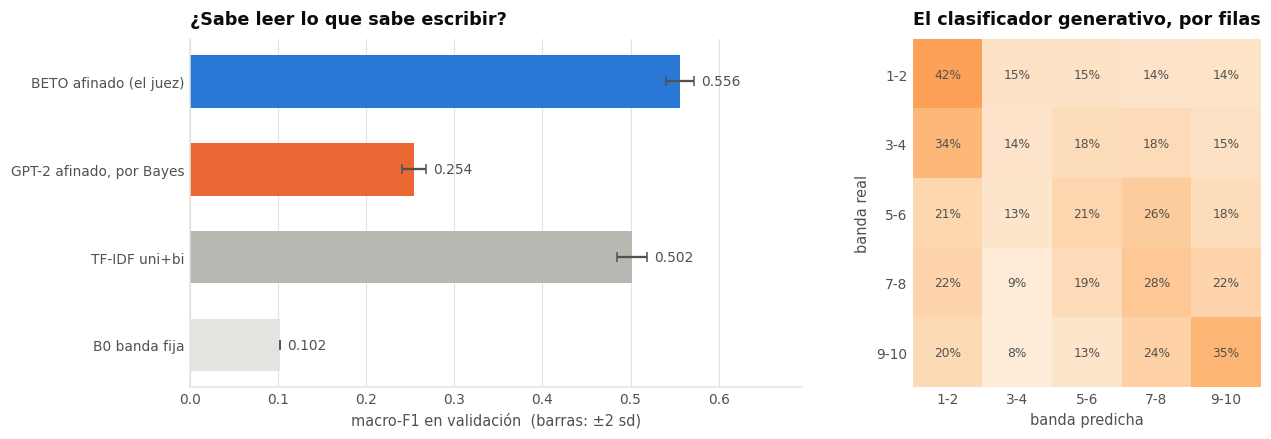

H5 · generativo − TF-IDF : -0.2482   (umbral 0.0218)
     generativo − BETO   : -0.3020   (umbral 0.0208)


In [32]:
filas_cmp = [("B0 banda fija", b0["macro_f1"], 0.0, MALLA),
             ("TF-IDF uni+bi", jt_val["macro_f1"], SD_TF, GRIS_REAL),
             ("GPT-2 afinado, por Bayes", g_val["macro_f1"], SD_G, NARANJA),
             ("BETO afinado (el juez)", jb_val["macro_f1"], SD_BET, AZUL)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.1), gridspec_kw={"width_ratios": [1.2, 1]})
y = np.arange(len(filas_cmp))
ax1.barh(y, [f[1] for f in filas_cmp], xerr=[2 * f[2] for f in filas_cmp],
         color=[f[3] for f in filas_cmp], height=.6, error_kw={"ecolor": TINTA_2, "capsize": 3})
for i, f in enumerate(filas_cmp):
    ax1.text(f[1] + 2 * f[2] + .008, i, f"{f[1]:.3f}", va="center", fontsize=9, color=TINTA_2)
ax1.set_yticks(y); ax1.set_yticklabels([f[0] for f in filas_cmp])
ax1.set_xlim(0, max(f[1] for f in filas_cmp) * 1.25)
ax1.set_xlabel("macro-F1 en validación  (barras: ±2 sd)")
ax1.set_title("¿Sabe leer lo que sabe escribir?")
ax1.grid(axis="x"); ax1.set_axisbelow(True); limpiar(ax1)

cm = g_val["confusion"] / np.maximum(g_val["confusion"].sum(1, keepdims=True), 1)
ax2.imshow(cm, cmap="Oranges", vmin=0, vmax=1)
for i in range(N_CLASES):
    for j in range(N_CLASES):
        ax2.text(j, i, f"{cm[i, j]:.0%}" if cm[i, j] >= .005 else "", ha="center", va="center",
                 fontsize=8, color="white" if cm[i, j] > .55 else TINTA_2)
ax2.set_xticks(ETIQUETAS); ax2.set_xticklabels(BANDAS)
ax2.set_yticks(ETIQUETAS); ax2.set_yticklabels(BANDAS)
ax2.set_xlabel("banda predicha"); ax2.set_ylabel("banda real")
ax2.set_title("El clasificador generativo, por filas")
for s in ax2.spines.values():
    s.set_visible(False)

plt.tight_layout(); guardar(fig, "08-clasificador-generativo"); plt.show()

UMBRAL_H5_TF = umbral(SD_G, SD_TF)
UMBRAL_H5_BE = umbral(SD_G, SD_BET)
DELTA_H5_TF = g_val["macro_f1"] - jt_val["macro_f1"]
DELTA_H5_BE = g_val["macro_f1"] - jb_val["macro_f1"]
print(f"H5 · generativo − TF-IDF : {DELTA_H5_TF:+.4f}   (umbral {UMBRAL_H5_TF:.4f})")
print(f"     generativo − BETO   : {DELTA_H5_BE:+.4f}   (umbral {UMBRAL_H5_BE:.4f})")

**H5 sale "parcial", pero en realidad falla.** El clasificador generativo saca 0,254 de macro-F1, por
encima del modelo que siempre dice la misma banda (0,102), pero muy por debajo del TF-IDF (0,502) y de
BETO (0,556). La parte que se cumple ("no llega a BETO") era la fácil; la que importaba ("supera al
TF-IDF") no se cumple.

Algo de señal tiene, y la matriz muestra que acierta sobre todo los extremos (42% en `1-2` y 35% en
`9-10`). Una explicación posible es que la diferencia entre tokens, aunque mínima en cada palabra, se va
sumando a lo largo de unos 250 tokens por crítica, y basta para inclinar la decisión cuando los cinco
valores están casi empatados. Sin el *prior* funciona mejor (0,254 contra 0,128), porque el *prior*
empuja todo hacia `7-8` cuando las verosimilitudes casi no difieren.

### 8.2 La partición de prueba, que se usa una sola vez

Las decisiones que dependían de validación ya están tomadas: el corte de contexto, usar o no el
*prior*, y la configuración principal, que se fijó antes de mirar. Ahora pasamos los tres lectores por
la partición de prueba, una sola vez, para comparar con el 0,554 que sacó el M3 en la Sesión 3.

In [33]:
ids_test = tok(list(df_test.texto))["input_ids"]
with medir("§8.2 prueba"):
    LL_test, _ = log_verosimilitud(gpt, ids_test, [[c] for c in CTRL_ID])
    pred_g_test = (LL_test + (PRIOR if USAR_PRIOR else 0)).argmax(1)
    pred_b_test, _ = juzgar_beto(list(df_test.texto))
    pred_t_test = juzgar_tfidf(df_test.texto)

y_test = df_test.y.values
prueba = {
    "TF-IDF uni+bi": evaluar(y_test, pred_t_test, nombre="J-tfidf", particion="test", verbose=False),
    "GPT-2 afinado, por Bayes": evaluar(y_test, pred_g_test, nombre="G-bayes", particion="test",
                                        notas=f"{'con' if USAR_PRIOR else 'sin'} prior",
                                        verbose=False),
    "BETO afinado (el juez)": evaluar(y_test, pred_b_test, nombre="J-beto", particion="test",
                                      verbose=False),
}
tabla_test = pd.DataFrame([{"lector": n, "macro-F1": m["macro_f1"], "QWK": m["qwk"],
                            "MAE": m["mae"], "accuracy": m["accuracy"]}
                           for n, m in prueba.items()])
print(tabla_test.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nReferencia Sesión 3 en prueba: TF-IDF 0,513 · BETO M3 0,554")

   ⏱  §8.2 prueba: 4.3 min   (acumulado 59.9 min)
                  lector  macro-F1    QWK    MAE  accuracy
           TF-IDF uni+bi    0.5130 0.6808 0.5903    0.5232
GPT-2 afinado, por Bayes    0.2581 0.1804 1.3135    0.2737
  BETO afinado (el juez)    0.5538 0.7575 0.5240    0.5533

Referencia Sesión 3 en prueba: TF-IDF 0,513 · BETO M3 0,554


Los dos jueces repiten en prueba la Sesión 3 casi al decimal: BETO 0,554 (igual) y TF-IDF 0,513
(igual). El clasificador generativo queda en 0,258, igual que en validación.

### 8.3 Lo que costó

In [34]:
gasto = pd.DataFrame(CRONO)
gasto["minutos"] = gasto.segundos / 60
print(gasto[["paso", "minutos"]].to_string(index=False, float_format=lambda v: f"{v:.1f}"))
print(f"\ntotal: {gasto.minutos.sum():.1f} min")

                                    paso  minutos
                        §5.1 juez TF-IDF      0.5
                          §5.2 juez BETO      8.6
         §5.2 juez BETO sobre validación      0.3
                  §6.2 fine-tuning GPT-2     35.1
    §6.3 log-verosimilitud en validación      4.8
§7.1 generación de las condiciones de H1      2.1
          §7.4 barrido de decodificación      4.1
§7.5 índice de 8-gramas de entrenamiento      0.1
                             §8.2 prueba      4.3

total: 59.9 min


Una hora en total. El *fine-tuning* de GPT-2 se llevó 35 minutos, más de la mitad, por los 512 tokens
de contexto. El juez BETO tomó 9.

### 8.4 Veredicto de las cinco hipótesis

La celda calcula cada veredicto a partir de los resultados y del criterio de §1.4.

In [35]:
def veredicto(ok, parcial=False):
    if parcial:
        return "PARCIAL"
    return "SE SOSTIENE" if ok else "REFUTADA"

h1_a, h1_b = QWK_BASE < 0.20, QWK_AFINADO >= 0.50
h2_ok = DELTA_H2 > UMBRAL_H2
h3_ok = BRECHA_H3 > 0.15
h4_a, h4_b = RHO_T_DIV >= 0.8, RHO_T_QWK <= -0.8
h5_a, h5_b = DELTA_H5_TF > UMBRAL_H5_TF, DELTA_H5_BE < -UMBRAL_H5_BE

ver = pd.DataFrame([
    {"hipótesis": "H1 · el token de control sí, el prompt no",
     "medida": f"QWK base {QWK_BASE:+.3f}; afinado {QWK_AFINADO:+.3f}",
     "veredicto": veredicto(h1_a and h1_b, parcial=(h1_a != h1_b))},
    {"hipótesis": "H2 · caricaturas",
     "medida": f"QWK generadas − reales {DELTA_H2:+.3f} (umbral {UMBRAL_H2:.3f}); "
               f"TF-IDF {DELTA_H2_TF:+.3f}",
     "veredicto": veredicto(h2_ok)},
    {"hipótesis": "H3 · el medio no se deja escribir",
     "medida": f"recall extremos − medio {BRECHA_H3:+.3f}",
     "veredicto": veredicto(h3_ok)},
    {"hipótesis": "H4 · temperatura: diversidad contra control",
     "medida": f"ρ(T, distinct-2) {RHO_T_DIV:+.2f}; ρ(T, QWK) {RHO_T_QWK:+.2f}",
     "veredicto": veredicto(h4_a and h4_b, parcial=(h4_a != h4_b))},
    {"hipótesis": "H5 · sabe leer lo que escribe",
     "medida": f"− TF-IDF {DELTA_H5_TF:+.3f}; − BETO {DELTA_H5_BE:+.3f}",
     "veredicto": veredicto(h5_a and h5_b, parcial=(h5_a != h5_b))},
])
pd.set_option("display.max_colwidth", 90)
print(ver.to_string(index=False))
print(f"\nControl de copia: el generador comparte {COPIA_GEN:.3f} de sus 8-gramas con el "
      f"entrenamiento; las reales de validación, {COPIA_REAL:.3f}.")

                                  hipótesis                                                      medida veredicto
  H1 · el token de control sí, el prompt no                             QWK base +0.111; afinado +0.054   PARCIAL
                           H2 · caricaturas QWK generadas − reales -0.722 (umbral 0.093); TF-IDF -0.646  REFUTADA
          H3 · el medio no se deja escribir                              recall extremos − medio -0.123  REFUTADA
H4 · temperatura: diversidad contra control                     ρ(T, distinct-2) +1.00; ρ(T, QWK) +0.30   PARCIAL
              H5 · sabe leer lo que escribe                              − TF-IDF -0.248; − BETO -0.302   PARCIAL

Control de copia: el generador comparte 0.000 de sus 8-gramas con el entrenamiento; las reales de validación, 0.001.


| Hipótesis | Medida | Veredicto |
|---|---|---|
| **H1** · el token sí, el *prompt* no | QWK base 0,111; afinado 0,054 | **PARCIAL** |
| **H2** · caricaturas | QWK generadas − reales −0,722 | **REFUTADA** |
| **H3** · el medio no se deja escribir | *recall* extremos − medio −0,123 | **REFUTADA** |
| **H4** · temperatura: variedad contra control | ρ(T, distinct-2) +1,00; ρ(T, QWK) +0,30 | **PARCIAL** |
| **H5** · sabe leer lo que escribe | − TF-IDF −0,248; − BETO −0,302 | **PARCIAL** |

Los veredictos hay que leerlos con cuidado. H1, H2 y H3 dependían de que el token de control
funcionara, y no funcionó por la razón de §6.3. Lo que se refuta es nuestro diseño, no las ideas
detrás de H2 y H3, que quedan sin probar. De H4 solo se pudo probar la parte de la diversidad, y se
cumplió. H5 sale parcial por la mitad fácil del criterio.

---

## 9. Demo y conclusiones

### 9.1 La misma película, cinco notas

El mismo comienzo, *"Una película"*, con cada token de control delante y la configuración principal.
Al lado, la banda que lee el juez y con qué seguridad. `escribir_critica()` queda disponible para
probar otros comienzos.

In [36]:
def escribir_critica(banda, inicio="", n=1, semilla=SEED, config=PRINCIPAL, max_nuevos=120):
    ids = [CTRL_ID[banda]] + (tok(inicio)["input_ids"] if inicio else [])
    torch.manual_seed(semilla)
    out = gpt.generate(torch.tensor([ids] * n, device=DEVICE),
                       attention_mask=torch.ones(n, len(ids), dtype=torch.long, device=DEVICE),
                       max_new_tokens=max_nuevos, pad_token_id=PAD_ID, eos_token_id=EOS_ID,
                       **DECODIFICACIONES[config])
    return [inicio + tok.decode(o[len(ids):], skip_special_tokens=True) for o in out]

demo = []
for k in ETIQUETAS:
    texto = escribir_critica(k, "Una película", semilla=SEED + 100 + k)[0]
    pred, P = juzgar_beto([texto])
    demo.append({"pedida": BANDAS[k], "leída": BANDAS[pred[0]],
                 "p(pedida)": f"{P[0, k]:.0%}", "crítica": texto.replace("\n", " ⏎ ")[:260]})
with pd.option_context("display.max_colwidth", 260):
    display(pd.DataFrame(demo))

muestra = juzgados[NOMBRE_PRINCIPAL].groupby("banda").sample(3, random_state=SEED)
muestra[["banda", "juez_beto", "p_pedida", "texto"]].assign(
    banda=lambda d: d.banda.map(NOMBRE), juez_beto=lambda d: d.juez_beto.map(NOMBRE)
).to_csv(RES / "muestras_s4.csv", index=False)
print(f"\n{len(muestra)} críticas generadas de muestra en {RES / 'muestras_s4.csv'}")

,pedida,leída,p(pedida),crítica
0,1-2,5-6,0%,"Una película de gracios de cinéfilos. ⏎ ⏎ Viendo los argumentos hay que decir que esta es, por lo menos, otra de esas películas de actores. No hay otra con algún dato semejante, pero estamos ante un film con un argumento muy conocido, con un guión claro y..."
1,3-4,9-10,0%,"Una película rodada con cariño y cariño ⏎ ⏎ Una maravilla de amor en su momento, con fuerza de guión y fuego en sus manos, y donde no hace falta gran ego ni lenguaje para transmitir sentimientos, sobre todo de nuestros personajes, hasta aquí es excelente...."
2,5-6,9-10,1%,"Una película que te transporta a lugares como Corrientes... a otra ciudad, a otro tiempo y a otra época..... es sorprendente !!!! ⏎ ⏎ Por muchos años la ficción en El precio justo en el Cine Argentino había sido una herramienta muy extendida en los cines...."
3,7-8,9-10,11%,"Una película muy especial ⏎ ⏎ Como siempre, la extraordinaria interpretación del director de los mejores efectos visuales del mundo. ⏎ ⏎ Como siempre, la impresionante fotografía de Steven Soderbergh, bella pero no un tanto espectaculada y premiable. No ..."
4,9-10,7-8,48%,"Una película de culto ⏎ ⏎ Me encuentro hoy aquí con una película que me ha gustado tanto como las demás, ya que sus propuestas hacen justicia a aquellas o, al menos, a aquella que tienen los aficionados al cine de Francia, más que un mero hecho promociona..."



15 críticas generadas de muestra en resultados/muestras_s4.csv


La demo resume el notebook. Las cinco críticas parecen escritas por usuarios de FilmAffinity, con
título, puntos suspensivos y opiniones sobre el guion y los actores. Pero la de `1-2` y la de `9-10`
podrían intercambiarse: el juez lee `5-6`, `9-10`, `9-10`, `9-10` y `7-8`.

---

### 9.2 Conclusiones

**1. El modelo aprendió a escribir críticas, pero no a escribir la nota pedida.** La perplejidad sobre
críticas que no vio bajó de 92 a 34, el vocabulario pasó de ficha de Wikipedia a opinión, el 37% de los
textos termina solo y no copia del entrenamiento. Pero el control no funcionó: QWK de 0,054 entre la
banda pedida y la leída, contra 0,775 con críticas reales.

**2. La causa fue dónde pusimos el token.** En GPT-2 la primera posición sirve para descargar
atención, y lo que identifica al token que hay ahí se pierde. Pusimos el token de control
justo ahí. Hay tres señales independientes de que el modelo no lo ve: la perplejidad es la misma con
el token correcto y con el opuesto (34,42 y 34,43), el siguiente token tiene casi la misma distribución
con los cinco controles, y la decodificación voraz escribe la misma crítica para las cinco bandas. Un
experimento corto lo confirmó: con un `<|endoftext|>` delante, el control pasa a la posición 1 y la
diferencia aparece.

**3. La señal estaba en los datos y no la miramos a tiempo.** La comparación entre banda correcta y
banda lejana de §6.3 cuesta cinco minutos, y ya en la prueba de humo daba lo mismo con los dos tokens.
La atribuimos al presupuesto mínimo. Con una revisión a tiempo nos habríamos ahorrado una corrida de
una hora. Queda como regla: antes de generar, comprobar que el modelo usa la condición.

**4. Los instrumentos funcionaron.** El juez BETO dio 0,554 en prueba, igual que en la Sesión 3, y el
TF-IDF 0,513, también igual. Gracias a eso podemos decir con confianza que el fallo está en el
generador y no en la forma de medirlo.

**5. Lo que sí se pudo medir.** La temperatura cambia la diversidad como se esperaba: de bucles
(repetición 0,75 a T = 0,3) a texto inventado (*distinct-2* 0,99 a T = 1,3). *top-p* 0,90 es lo que
más se parece a las críticas reales. Y corregir el `<pad>` del guía hizo que el modelo aprendiera a
terminar sus textos.

**6. Lo que queda por hacer.** Volver a correr con el token de control en la posición 1, sin más
cambios. Solo entonces se pueden contrastar de verdad H2 (caricaturas) y H3 (el medio no se deja
escribir), y el diagnóstico sugiere que funcionará. Otra opción es poner la nota en texto
(*"Nota: 1-2."*), que usa palabras que el modelo ya conoce.

### Las cuatro entregas

| | Conclusión |
|---|---|
| **Sesión 1** | En *abstracts* médicos la señal es léxica: TF-IDF (0,530) le gana a una LSTM (0,268). |
| **Sesión 2** | Un transformer desde cero, capaz de usar el orden de las palabras, no lo usa. Gana otra vez el TF-IDF. |
| **Sesión 3** | Con preentrenamiento, BETO sí usa el orden y por fin le gana al TF-IDF (0,554 contra 0,513). |
| **Sesión 4** | GPT-2 aprende a escribir críticas, pero no la nota que se le pide: el token de control quedó en una posición que el modelo no lee. El juez de la Sesión 3 repite sus cifras exactas. |

En la Sesión 2 vimos que un modelo puede tener una capacidad y no usarla. Aquí nos pasó lo mismo con
el token de control: el modelo lo tenía delante y no lo usó. En los dos casos el problema apareció
porque teníamos una medida que lo dejaba ver.

---

### Referencias

- Radford, A. *et al.* (2019). *Language Models are Unsupervised Multitask Learners.* OpenAI. — GPT-2.
- Keskar, N. S. *et al.* (2019). *CTRL: A Conditional Transformer Language Model for Controllable
  Generation.* arXiv:1909.05858. — los códigos de control.
- Holtzman, A. *et al.* (2020). *The Curious Case of Neural Text Degeneration.* ICLR. — el muestreo
  *top-p* y los bucles de la decodificación voraz.
- Xiao, G. *et al.* (2024). *Efficient Streaming Language Models with Attention Sinks.* ICLR. — la
  primera posición como lugar de descarga de la atención.
- Sun, M. *et al.* (2024). *Massive Activations in Large Language Models.* COLM. — las activaciones
  enormes de la primera posición.
- Li, J. *et al.* (2016). *A Diversity-Promoting Objective Function for Neural Conversation Models.*
  NAACL. — *distinct-n*.
- Carlini, N. *et al.* (2021). *Extracting Training Data from Large Language Models.* USENIX Security. —
  por qué medir la copia.
- Cañete, J. *et al.* (2020). *Spanish Pre-Trained BERT Model and Evaluation Data.* PML4DC @ ICLR. —
  BETO, el juez.
- Conjunto de datos `naim-prog/filmaffinity-reviews-info` (licencia MIT), HuggingFace Hub.
- Modelo `mrm8488/spanish-gpt2`, HuggingFace Hub.
- Notebook guía: `1-text-generation.ipynb`, de `Ohtar10/icesi-nlp`.